In [42]:
#import sys
#!{sys.executable} -m pip install pandas
#import sys
#!{sys.executable} -m pip install seaborn

# Régression par Splines Pénalisées : Notebook Exploratoire

Ce notebook contient une implémentation exploratoire initiale du pipeline
de régression par B-splines pénalisées, développée avant la mise en place
du cadre de comparaison unifié.

**Note :** Il ne s'agit pas de la version utilisée pour produire les résultats
présentés dans l'article. L'implémentation finale se trouve dans
`pipeline_integrale.ipynb`, qui intègre toutes les méthodes de régression
(spline multi-échelle, STL, Fourier) dans un pipeline unifié.

Les fonctions définies ici (`build_bspline_basis`, `penalized_spline_fit`,
`optimize_lambda_gcv`, etc.) ont été consolidées dans `function.py`
et sont importées par le pipeline principal.

In [43]:
import csv
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt  
from ipywidgets import interact, FloatSlider
from datetime import datetime

import os

import numpy as np
from numpy.linalg import solve

import pandas as pd
from scipy.interpolate import BSpline

import seaborn as sns

from scipy.linalg import lstsq

from scipy.stats import pearsonr

import matplotlib.dates as mdates

# Traitement de la série temporelle 

In [44]:
# Préparation des dataframes des séries temporelles
def prepadataframe(Paracou=1, allROI=0): 
    #### PARACOU=1 : on fait sur paracou, si PARACOU=0 on fait sur trinité
    #### ALLROI : si on fait sur paracou, on voit si on utilise ALLROI ou Tropiscat grace a ALLROI
    '''''----- ATTENTION, si on utilise Paracou= 1 ça renvoie value et date, si Paracou =0 ça renvoie masked, unmasked et date-----------'''''''''''
    if Paracou==1:
        Data_file = "data/Data/S1A_ASC-DSC_VV-VH_Paracou"        
        df_VH_ASC_TropiScat = pd.read_csv(f"{Data_file}/s1a_vh_ASC_047_TropiScat.csv")
        df_VH_DSC_TropiScat =  pd.read_csv(f"{Data_file}/s1a_vh_DSC_039_TropiScat.csv")
        df_VV_ASC_TropiScat =  pd.read_csv(f"{Data_file}/s1a_vv_ASC_047_TropiScat.csv")
        df_VV_DSC_TropiScat =  pd.read_csv(f"{Data_file}/s1a_vv_DSC_039_TropiScat.csv")
        
        dfs_TropiScat = {
            "VV_ASC": df_VV_ASC_TropiScat,
            "VH_ASC": df_VH_ASC_TropiScat,
            "VV_DSC": df_VV_DSC_TropiScat,
            "VH_DSC": df_VH_DSC_TropiScat,
        }
        df_VH_ASC_allROI =  pd.read_csv(f"{Data_file}/s1a_vh_ASC_047_allROI.csv")
        df_VH_DSC_allROI =  pd.read_csv(f"{Data_file}/s1a_vh_DSC_039_allROI.csv")
        df_VV_ASC_allROI =  pd.read_csv(f"{Data_file}/s1a_vv_ASC_047_allROI.csv")
        df_VV_DSC_allROI =  pd.read_csv(f"{Data_file}/s1a_vv_DSC_039_allROI.csv")
        
        dfs_allROI = {
            "VV_ASC": df_VV_ASC_allROI,
            "VH_ASC": df_VH_ASC_allROI,
            "VV_DSC": df_VV_DSC_allROI,
            "VH_DSC": df_VH_DSC_allROI,
        }
        
        
        value_TropiScat= {
            "VV_ASC": df_VV_ASC_TropiScat.select_dtypes(include='number').to_numpy(),
            "VH_ASC": df_VH_ASC_TropiScat.select_dtypes(include='number').to_numpy(),
            "VV_DSC": df_VV_DSC_TropiScat.select_dtypes(include='number').to_numpy(),
            "VH_DSC": df_VH_DSC_TropiScat.select_dtypes(include='number').to_numpy(),
        }
        
        value_allROI = {
            "VV_ASC": df_VV_ASC_allROI.select_dtypes(include='number').to_numpy(),
            "VH_ASC": df_VH_ASC_allROI.select_dtypes(include='number').to_numpy(),
            "VV_DSC": df_VV_DSC_allROI.select_dtypes(include='number').to_numpy(),
            "VH_DSC": df_VH_DSC_allROI.select_dtypes(include='number').to_numpy(),
        }
        
        date_TropiScat= {
            "VV_ASC": np.array(df_VV_ASC_TropiScat)[:,0],
            "VH_ASC": np.array(df_VH_ASC_TropiScat)[:,0],
            "VV_DSC": np.array(df_VV_DSC_TropiScat)[:,0],
            "VH_DSC": np.array(df_VH_DSC_TropiScat)[:,0],
        }
        date_allROI= {
            "VV_ASC": np.array(df_VV_ASC_allROI)[:,0],
            "VH_ASC": np.array(df_VH_ASC_allROI)[:,0],
            "VV_DSC": np.array(df_VV_DSC_allROI)[:,0],
            "VH_DSC": np.array(df_VH_DSC_allROI)[:,0],
        }
        if allROI==1:
            return value_allROI,date_allROI
        else:
            return value_TropiScat,date_TropiScat
            
    else:
        Data_file="data/Data/StudyCase_S1_Trinité"
        df_VH_ASC_Trinit = pd.read_csv(f"{Data_file}/ts_s1a_21NZF_vh_ASC_120_867km2.csv")
        df_VV_ASC_defoliated_Trinit =  pd.read_csv(f"{Data_file}/ts_s1a_21NZF_vv_ASC_120_1ha-defoliated.csv")
        df_VV_ASC_Trinit =  pd.read_csv(f"{Data_file}/ts_s1a_21NZF_vv_ASC_120_867km2.csv")


        dfs_Trinit = {
            "VV_ASC": df_VV_ASC_Trinit,
            "VH_ASC": df_VH_ASC_Trinit,
            "VV_DEFOL": df_VV_ASC_defoliated_Trinit,
        }


        moy_masked_Trinit= {
            "VV_ASC": df_VV_ASC_Trinit.select_dtypes(include='number').to_numpy()[:,0],
            "VH_ASC": df_VH_ASC_Trinit.select_dtypes(include='number').to_numpy()[:,0],
            "VV_DEFOL": df_VV_ASC_defoliated_Trinit.select_dtypes(include='number').to_numpy()[:,0],
        }
        moy_unmasked_Trinit= {
            "VV_ASC": df_VV_ASC_Trinit.select_dtypes(include='number').to_numpy()[:,1],
            "VH_ASC": df_VH_ASC_Trinit.select_dtypes(include='number').to_numpy()[:,1],
            "VV_DEFOL": df_VV_ASC_defoliated_Trinit.select_dtypes(include='number').to_numpy()[:,1],
        }

        
        date_Trinit= {
            "VV_ASC": np.array(df_VV_ASC_Trinit)[:,0],
            "VH_ASC": np.array(df_VH_ASC_Trinit)[:,0],
            "VV_DEFOL": np.array(df_VV_ASC_defoliated_Trinit)[:,0],
        }
        return moy_masked_Trinit,moy_unmasked_Trinit,date_Trinit


# Modèle théorique 

Formulation spline :

$$ s(t) = \sum_{j=1}^{K} \beta_j B_j(t) $$

- $B_j(t)$ → fonctions de base B-splines  

- $\beta_j$ → coefficients à estimer  

- $K$ → nombre de fonctions de base (dépend du nombre de nœuds)

Critère pénalisé :

$$ \hat{\beta} = \arg\min_{\beta} \left( \sum (Y - B\beta)^2 + \lambda \sum \beta_j^2 \right) $$


## Implémentation de la base B_Spline

On définit la matrice de base spline :

$$
B =
\begin{bmatrix}
B_1(t_1) & \dots & B_K(t_1) \\
\vdots & \ddots & \vdots \\
B_1(t_n) & \dots & B_K(t_n)
\end{bmatrix}
$$

Chaque ligne correspond à une observation temporelle $t_i$  
Chaque colonne correspond à une fonction de base $B_j(t)$  

In [45]:

def build_bspline_basis(t, n_knots, degree=3):
    # Noeuds INTERNES seulement (sans les bornes)
    knots_internal = np.linspace(t.min(), t.max(), n_knots + 2)[1:-1]  # ← exclure bornes
    
    knots = np.concatenate(([t.min()] * (degree + 1),
                             knots_internal,
                            [t.max()] * (degree + 1)))  # ← multiplicité degree+1
    
    K = len(knots) - degree - 1
    B = np.zeros((len(t), K))
    
    for j in range(K):
        coeff = np.zeros(K)
        coeff[j] = 1
        spline_basis = BSpline(knots, coeff, degree)
        B[:, j] = spline_basis(t)
    
    return B

## Regression de la Spline Pénalisée

In [46]:
def penalty_matrix(K, order=2):
    D = np.diff(np.eye(K), n=order, axis=0)
    return D.T @ D

def penalized_spline_fit(B, Y, lam):
    K = B.shape[1]
    P = penalty_matrix(K)  # ← remplace np.eye
    beta = solve(B.T @ B + lam * P, B.T @ Y)
    return beta, B @ beta

## Matrice de Lissage

$$ S_\lambda = B(B^TB + \lambda I)^{-1}B^T $$

$$ EDF(\lambda) = \mathrm{trace}(S_\lambda) $$


In [47]:
def smoothing_matrix(B, lam):
    K = B.shape[1]
    P = penalty_matrix(K)
    return B @ solve(B.T @ B + lam * P, B.T)

def compute_edf(B, lam):
    return np.trace(smoothing_matrix(B, lam))

## Optimisation de λ via GCV 

$$ GCV(\lambda) = \frac{n \sum (Y - \hat{s}_\lambda)^2}{(n - EDF(\lambda))^2} $$


In [48]:
def gcv_score(B, Y, lam):
    n = len(Y)
    _, Y_hat = penalized_spline_fit(B, Y, lam)
    residual = np.sum((Y - Y_hat)**2)
    edf = compute_edf(B, lam)
    return (n * residual) / ((n - edf)**2)

def optimize_lambda_gcv(B, Y):
    lambdas = np.logspace(-4, 4, 100)
    scores = np.array([gcv_score(B, Y, lam) for lam in lambdas])
    return lambdas[np.argmin(scores)]

# Modélisation

## Zone régionale

In [49]:
# FONCTION PRINCIPALE MODÉLISATION RÉGIONALE
def regional_penalized_model(t, Y_reg,n, lam=None, auto_lambda=False):
    B = build_bspline_basis(t,n)
    
    if auto_lambda:
        lam = optimize_lambda_gcv(B, Y_reg)
        print("Lambda optimal (GCV) =", lam)
    elif lam is None:
        lam = 1.0
    
    beta, Y_hat = penalized_spline_fit(B, Y_reg, lam)
    EDF = compute_edf(B, lam)
    omega_c = lam**(-1/4)
    
    print("EDF =", EDF)
    print("Fréquence de coupure ω_c =", omega_c)
    
    return Y_hat, lam, EDF, omega_c

## Affichage Splines Superposées

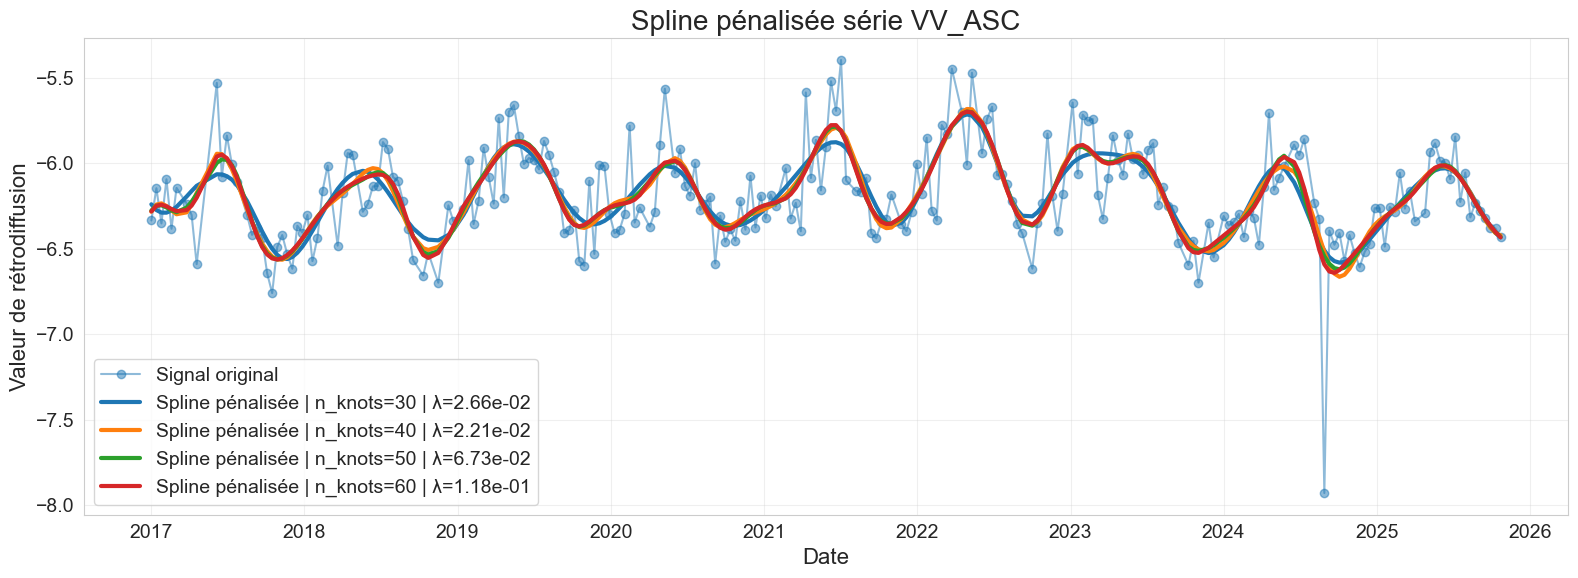

In [50]:
# --- Paramètres du plot ---
knot_list = [30, 40, 50, 60]  # nombres de noeuds pour les splines
roi_index = 0                 
series_to_plot = "VV_ASC"     # VV_ASC ou VH_ASC 

# Régional/Local sot allROI ou Tropiscat

value_source,date_source  = prepadataframe(1,1)


# Préparer les données pour la série choisie
dates = date_source[series_to_plot]
values_array = value_source[series_to_plot]

# s'assurer que values_array est 2D
if values_array.ndim == 1:
    values_array = values_array[:, np.newaxis]

# ajuster roi_index si nécessaire
roi_idx = min(roi_index, values_array.shape[1]-1)
values = values_array[:, roi_idx]

# temps numérique pour les splines
t = np.arange(len(dates))
fs = 1  # fréquence fictive (optionnel)

# 🎨 Style propre type publication
sns.set_style("whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "legend.fontsize": 14
})

# Affichage
dates = pd.to_datetime(dates)
t_numeric = np.array([(d - dates[0]).days for d in dates])

plt.figure(figsize=(16, 6))  # figure large et lisible

# 🔵 Signal original (points reliés, semi-transparents)
plt.plot(
    dates,
    values,
    '-o',
    color='tab:blue',
    alpha=0.5,
    linewidth=1.5,
    markersize=6,
    label="Signal original"
)

# 🟠 Superposition des splines
for n_knots in knot_list:
    B = build_bspline_basis(t_numeric, n_knots)
    lam_opt = optimize_lambda_gcv(B, values)
    _, Y_hat = penalized_spline_fit(B, values, lam_opt)
    
    plt.plot(
        dates,
        Y_hat,
        linewidth=3,   # spline bien visible
        label=f"Spline pénalisée | n_knots={n_knots} | λ={lam_opt:.2e}"
    )

# Titres et axes
plt.title(f"Spline pénalisée série {series_to_plot}")
plt.xlabel("Date")
plt.ylabel("Valeur de rétrodiffusion")

plt.legend()
plt.tight_layout()
plt.show()

## Affichage Splines Séparées 

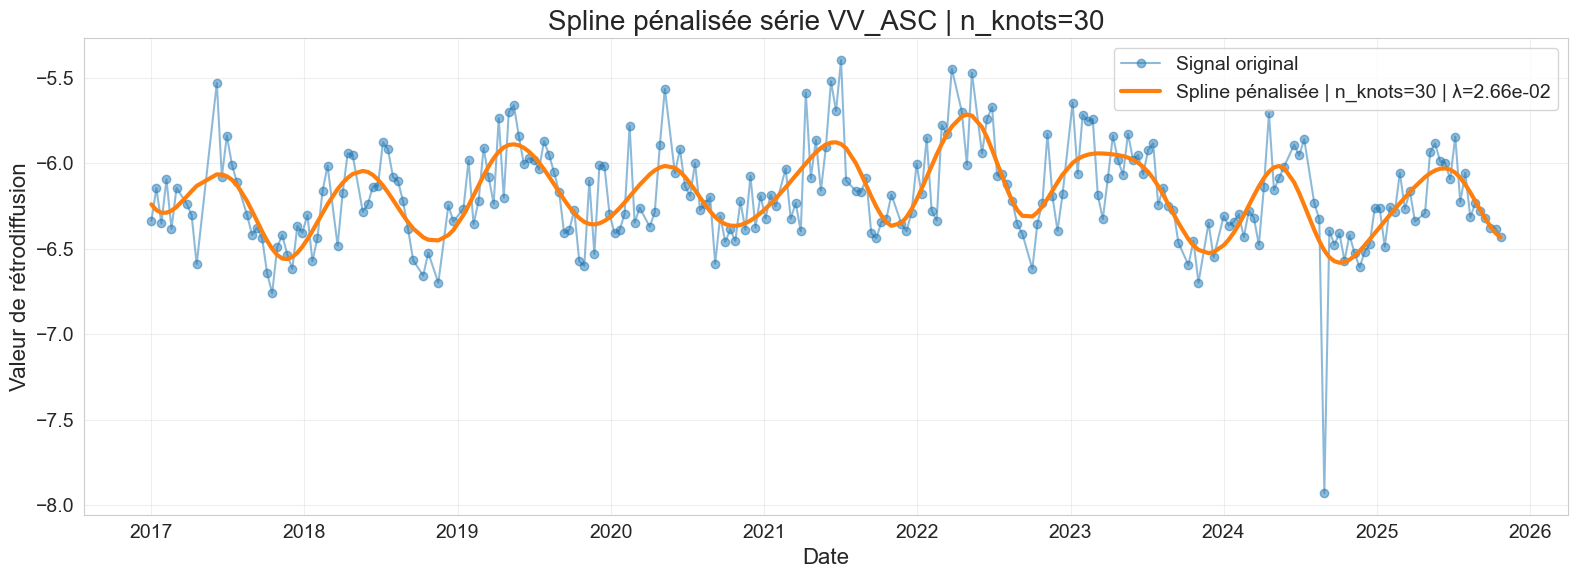

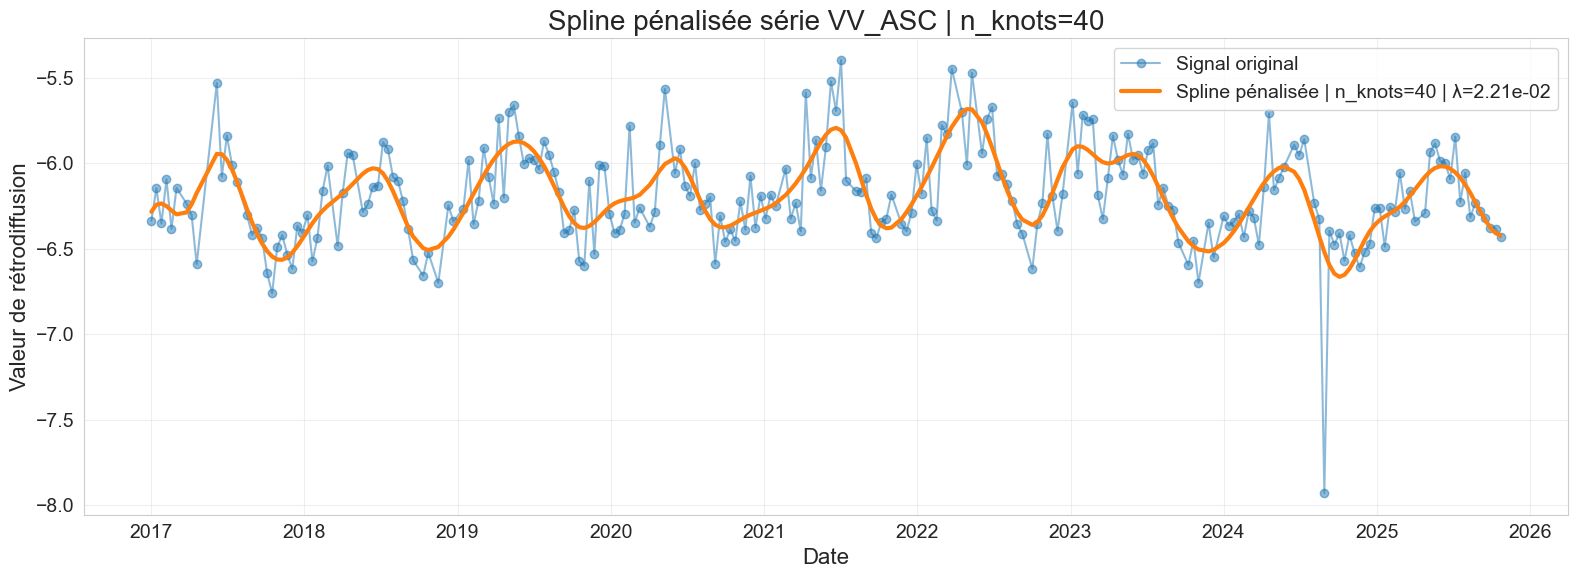

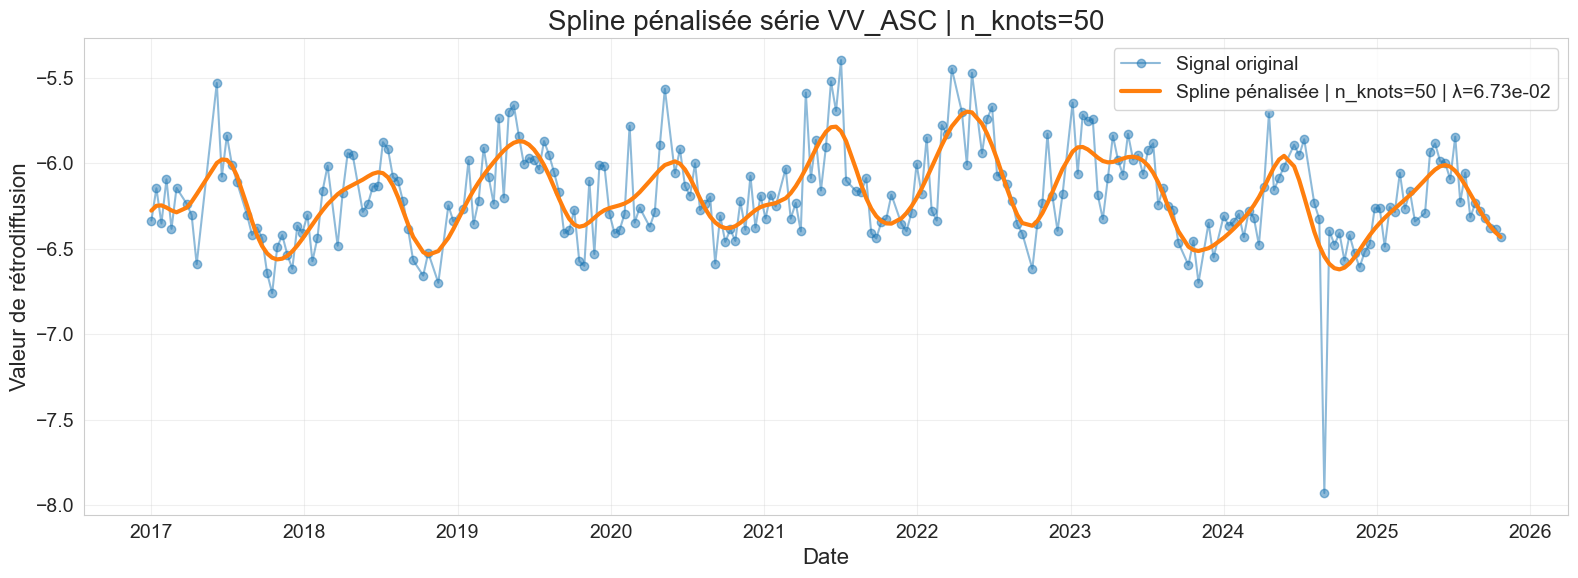

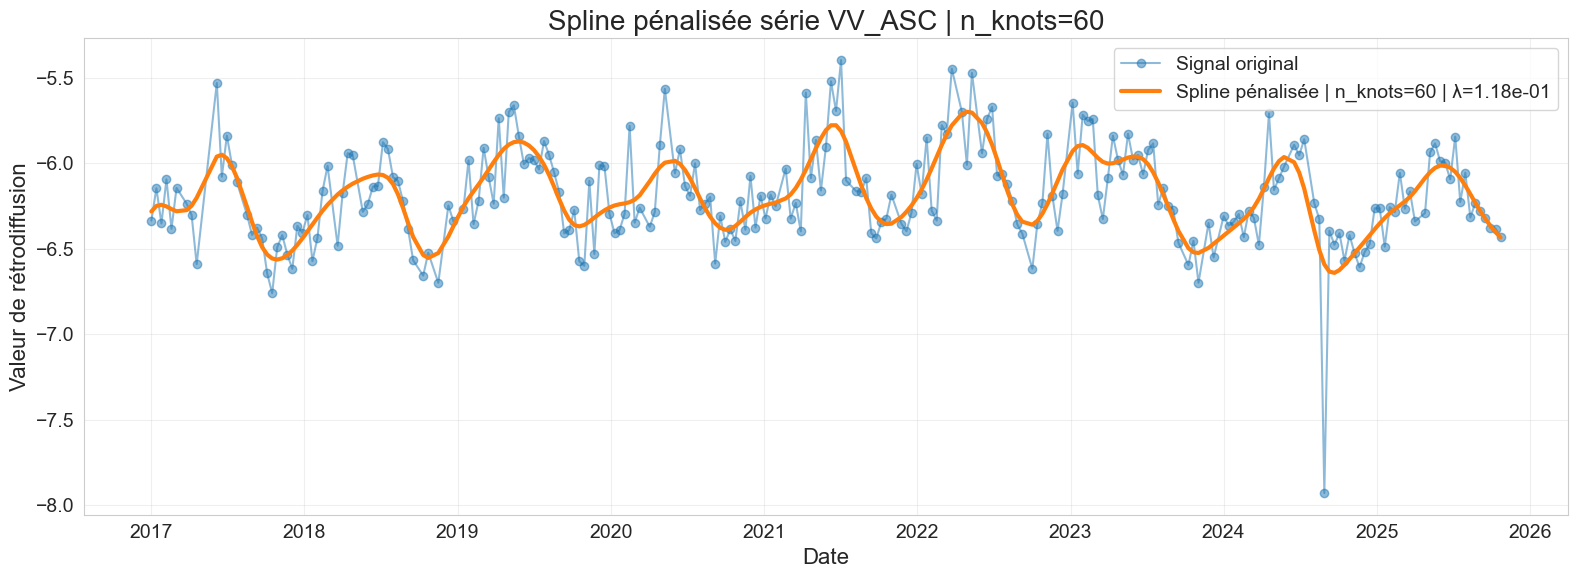

In [51]:

# Conversion des dates en format numérique pour les splines
dates = pd.to_datetime(dates)
t_numeric = np.array([(d - dates[0]).days for d in dates])

# Boucle sur chaque nombre de nœuds
for n_knots in knot_list:
    plt.figure(figsize=(16, 6))
    
    # Signal original
    plt.plot(
        dates,
        values,
        '-o',
        color='tab:blue',
        alpha=0.5,
        linewidth=1.5,
        markersize=6,
        label="Signal original"
    )
    
    # Spline pénalisée pour ce nombre de nœuds
    B = build_bspline_basis(t_numeric, n_knots)
    lam_opt = optimize_lambda_gcv(B, values)
    _, Y_hat = penalized_spline_fit(B, values, lam_opt)
    
    plt.plot(
        dates,
        Y_hat,
        color='tab:orange',
        linewidth=3,
        label=f"Spline pénalisée | n_knots={n_knots} | λ={lam_opt:.2e}"
    )
    
    # Titres et axes
    plt.title(f"Spline pénalisée série {series_to_plot} | n_knots={n_knots}")
    plt.xlabel("Date")
    plt.ylabel("Valeur de rétrodiffusion")
    
    plt.legend()
    plt.tight_layout()
    plt.show()

# Sélection du nombre de nœuds

Pour ajuster une spline pénalisée aux séries temporelles SAR, il est nécessaire de choisir
le nombre de nœuds $J$ de manière automatique et rigoureuse. On utilise ici la méthode de
**suppression pas à pas** (*stepwise deletion*) décrite par Kooperberg & Stone (1991),
combinée au critère de **Mallows $C_p$ modifié**.


## Théorie 

### Principe 




On part d'un grand nombre de nœuds initiaux $J_0 = \lfloor T/3 \rfloor$, placés aux
quantiles réguliers du temps. À chaque étape $j$, on supprime un nœud et on évalue la
qualité du modèle résultant via le critère :

$$C_j = \text{RSS}_j + \alpha \cdot (J_0 + 4 - j) \cdot \hat{\sigma}^2$$

où :
- $\text{RSS}_j$ est la somme des carrés des résidus du modèle à l'étape $j$
- $J_0 + 4 - j$ est le nombre de paramètres libres (les $J_0 - j$ nœuds restants + 4 termes polynomiaux de la base cubique)
- $\hat{\sigma}^2 = \text{RSS}_0 / (T - J_0 - 4)$ est la variance résiduelle estimée **une seule fois** sur le modèle complet initial, et fixée pour toutes les étapes
- $\alpha$ est un paramètre de lissage : $\alpha = 3$ est recommandé par Kooperberg & Stone (1991), $\alpha = 2$ correspond à l'AIC, et $\alpha = \log T$ au BIC

Le terme $\alpha \cdot (J_0 + 4 - j) \cdot \hat{\sigma}^2$ joue le rôle d'une **pénalité sur
la complexité** : il augmente avec le nombre de paramètres, ce qui décourage le
sur-ajustement. 
Le modèle retenu $\hat{j}$ est celui qui **minimise $C_j$**, réalisant le
meilleur compromis entre fidélité aux données ($\text{RSS}_j$ faible) et parcimonie
(peu de nœuds).

### Lien avec la spline pénalisée



Une fois le nombre de nœuds $\hat{J}$ sélectionné, la base B-spline cubique est construite
avec $\hat{J}$ nœuds internes, et le paramètre de lissage $\lambda$ est optimisé
automatiquement par **validation croisée généralisée** (GCV) :

$$\text{GCV}(\lambda) = \frac{T \cdot \text{RSS}(\lambda)}{\left(T - \text{EDF}(\lambda)\right)^2}$$

où $\text{EDF}(\lambda) = \text{tr}(\mathbf{H}_\lambda)$ est le nombre de degrés de liberté
effectifs de la spline pénalisée, avec $\mathbf{H}_\lambda = \mathbf{B}(\mathbf{B}^\top\mathbf{B} + \lambda \mathbf{I})^{-1}\mathbf{B}^\top$.

La sélection se fait donc en deux étapes indépendantes :
1. **Nombre de nœuds** $\hat{J}$ → critère de Mallows $C_p$
2. **Intensité de la pénalisation** $\hat{\lambda}$ → critère GCV

## Fonction de sélection du nombre de nœuds optimal 

In [52]:

# ════════════════════════════════════════════════════════════
#  SÉLECTION DU NOMBRE DE NŒUDS OPTIMAL (Mallows Cp)
# ════════════════════════════════════════════════════════════

def stepwise_knot_selection_bspline(x, y, alpha=3.0, verbose=True):
    n = len(x)
    min_knots = 5
    n_init = max(min_knots, n // 3)
    quantiles = np.linspace(0, 100, n_init + 2)[1:-1]
    J = len(quantiles)

    B_full = build_bspline_basis(x, J)
    lam_full = optimize_lambda_gcv(B_full, y)
    _, y_hat_full = penalized_spline_fit(B_full, y, lam_full)
    rss_full = np.sum((y - y_hat_full)**2)
    p_full = J + 4
    sigma2_hat = rss_full / max(n - p_full, 1)

    Cp_init = rss_full + alpha * p_full * sigma2_hat
    history = {"Cp": [Cp_init], "RSS": [rss_full], "n_knots": [J]}

    if verbose:
        print(f"  {'# nœuds':>8}  {'p=nœuds+4':>10}  {'RSS':>14}  {'Cp':>14}")
        print("  " + "-" * 54)
        print(f"  {J:>8}  {p_full:>10}  {rss_full:>14.4f}  {Cp_init:>14.4f}  ← modèle initial")

    for step in range(J - 1, min_knots - 1, -1):
        p_j = step + 4
        B   = build_bspline_basis(x, step)
        lam = optimize_lambda_gcv(B, y)
        _, y_hat = penalized_spline_fit(B, y, lam)
        rss = np.sum((y - y_hat)**2)
        Cp  = rss + alpha * p_j * sigma2_hat

        history["Cp"].append(Cp)
        history["RSS"].append(rss)
        history["n_knots"].append(step)

        if verbose:
            marker = "  ← optimal" if Cp == min(history["Cp"]) else ""
            print(f"  {step:>8}  {p_j:>10}  {rss:>14.4f}  {Cp:>14.4f}{marker}")

    best_idx     = np.argmin(history["Cp"])
    best_n_knots = history["n_knots"][best_idx]

    if verbose:
        print(f"\n  ✓ Nœuds optimal : {best_n_knots}  |  Cp = {history['Cp'][best_idx]:.4f}")

    return best_n_knots, history




# Spline Régionale Optimale 

Série : VV_ASC  |  ROI index : 0  |  n = 243
Sélection du nombre de nœuds (alpha=3.0) ...

   # nœuds   p=nœuds+4             RSS              Cp
  ------------------------------------------------------
        81          85          8.1509         21.3059  ← modèle initial
        80          84          8.1789         21.1791  ← optimal
        79          83          8.2450         21.0905  ← optimal
        78          82          8.1375         20.8282  ← optimal
        77          81          8.1644         20.7003  ← optimal
        76          80          8.1900         20.5712  ← optimal
        75          79          8.1037         20.3301  ← optimal
        74          78          8.1421         20.2137  ← optimal
        73          77          8.1954         20.1123  ← optimal
        72          76          8.2557         20.0178  ← optimal
        71          75          8.2962         19.9035  ← optimal
        70          74          8.1766         19.6291  ← optima

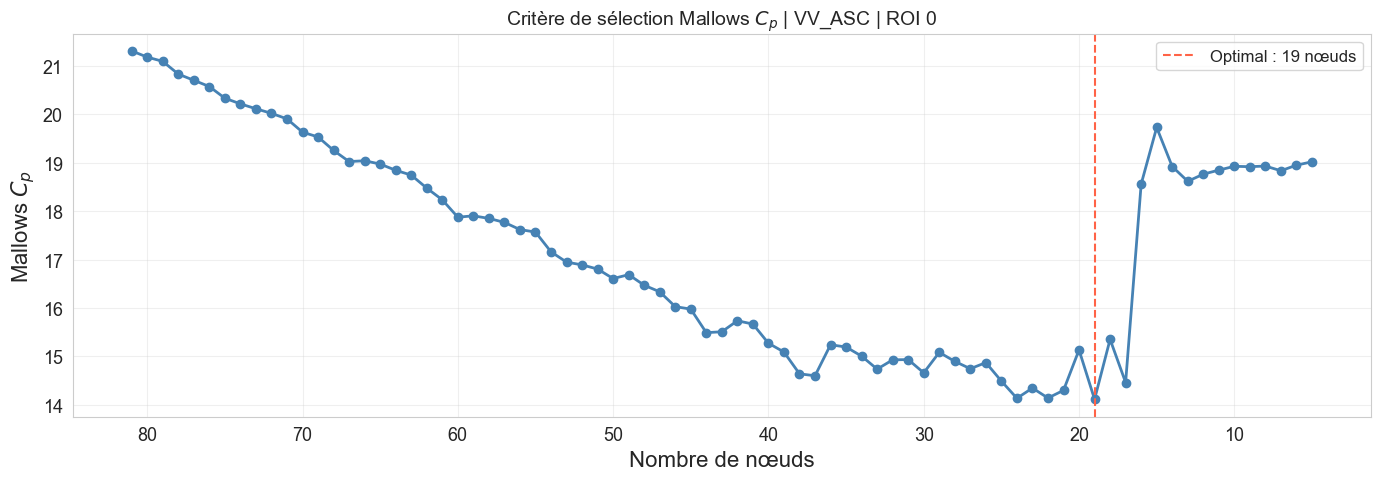

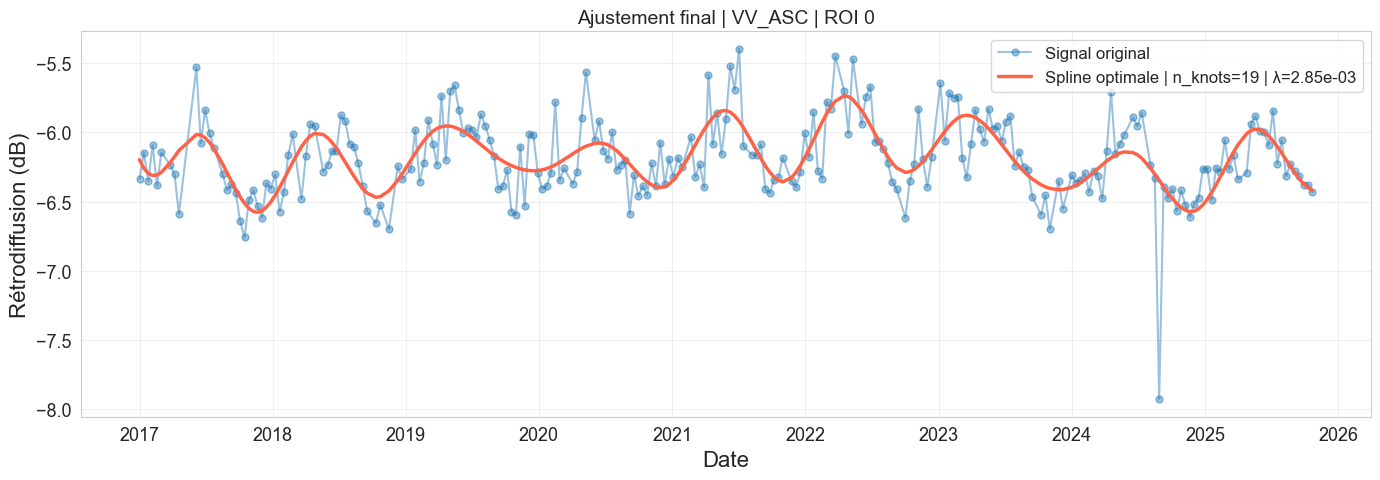

In [53]:
# ════════════════════════════════════════════════════════════
#  PARAMÈTRES | à modifier ici uniquement
# ════════════════════════════════════════════════════════════

series_to_plot = "VV_ASC"        # "VV_ASC" | "VH_ASC" | "VV_DSC" | "VH_DSC"
roi_index      = 0                # index de la ROI
value_source,date_source   = prepadataframe(1,1)   
alpha          = 3.0              # paramètre Mallows Cp (3=Kooperberg, 2=AIC, log(n)=BIC)

# ════════════════════════════════════════════════════════════
#  PRÉPARATION DES DONNÉES
# ════════════════════════════════════════════════════════════

dates = pd.to_datetime(date_source[series_to_plot])
values_array = value_source[series_to_plot]
if values_array.ndim == 1:
    values_array = values_array[:, np.newaxis]
roi_idx = min(roi_index, values_array.shape[1] - 1)
values = values_array[:, roi_idx]

t_numeric = np.array([(d - dates[0]).days for d in dates], dtype=float)

print(f"Série : {series_to_plot}  |  ROI index : {roi_idx}  |  n = {len(values)}")
print(f"Sélection du nombre de nœuds (alpha={alpha}) ...\n")
n_knots_optimal, history = stepwise_knot_selection_bspline(t_numeric, values, alpha=alpha)

# ════════════════════════════════════════════════════════════
#  AJUSTEMENT FINAL
# ════════════════════════════════════════════════════════════

B        = build_bspline_basis(t_numeric, n_knots_optimal)
lam_opt  = optimize_lambda_gcv(B, values)
_, Y_hat = penalized_spline_fit(B, values, lam_opt)

# ════════════════════════════════════════════════════════════
#  VISUALISATION | graphe 1 : critère Cp
# ════════════════════════════════════════════════════════════

sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 13, "axes.titlesize": 14, "legend.fontsize": 12})

plt.figure(figsize=(14, 5))
plt.plot(history["n_knots"], history["Cp"], "o-", color="steelblue", linewidth=2)
plt.axvline(n_knots_optimal, color="tomato", linestyle="--",
            label=f"Optimal : {n_knots_optimal} nœuds")
plt.xlabel("Nombre de nœuds")
plt.ylabel("Mallows $C_p$")
plt.title(f"Critère de sélection Mallows $C_p$ | {series_to_plot} | ROI {roi_idx}")
plt.gca().invert_xaxis()
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════
#  VISUALISATION | graphe 2 : ajustement final
# ════════════════════════════════════════════════════════════

plt.figure(figsize=(14, 5))
plt.plot(dates, values, '-o', color='tab:blue', alpha=0.45,
         linewidth=1.5, markersize=5, label="Signal original")
plt.plot(dates, Y_hat, color='tomato', linewidth=2.5,
         label=f"Spline optimale | n_knots={n_knots_optimal} | λ={lam_opt:.2e}")
plt.xlabel("Date")
plt.ylabel("Rétrodiffusion (dB)")
plt.title(f"Ajustement final | {series_to_plot} | ROI {roi_idx}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
def plot_superpose_annees_spline(t_numeric, Y_hat, dates, nom, title=None):
    """
    Superpose les années de la spline pénalisée.
    On réévalue la spline sur une grille journalière pour avoir une courbe continue.
    """
    from scipy.interpolate import interp1d
    
    # Interpolation de Y_hat sur une grille journalière
    t_dense = np.arange(t_numeric.min(), t_numeric.max(), 1)  # 1 point/jour
    spline_interp = interp1d(t_numeric, Y_hat, kind='cubic')
    Y_dense = spline_interp(t_dense)
    
    # Reconstruction des dates journalières
    date_origin = dates[0]
    dates_dense = [date_origin + pd.Timedelta(days=int(t)) for t in t_dense]
    
    df_plot = pd.DataFrame({
        "date":  dates_dense,
        "value": Y_dense,
        "year":  [d.year for d in dates_dense],
        "doy":   [d.timetuple().tm_yday for d in dates_dense],
    })
    
    years  = sorted(df_plot["year"].unique())
    colors = plt.cm.viridis(np.linspace(0, 1, len(years)))
    
    fig, ax = plt.subplots(figsize=(14, 5))
    
    for year, color in zip(years, colors):
        df_year = df_plot[df_plot["year"] == year].sort_values("doy")
        ax.plot(df_year["doy"], df_year["value"],
                linewidth=1.5, color=color, label=str(year))
    
    ax.set_xlabel("Jour de l'année", fontsize=11)
    ax.set_ylabel("Backscatter [dB]", fontsize=11)
    ax.set_title(title or f"Superposition des années (spline) | {nom}", fontsize=12, fontweight="bold")
    ax.set_xlim(1, 365)
    ax.set_xticks([1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335])
    ax.set_xticklabels(["Jan","Fév","Mar","Avr","Mai","Jun",
                        "Jul","Aoû","Sep","Oct","Nov","Déc"], fontsize=9)
    ax.legend(title="Année", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_superpose_annees(value, dates_dict, nom, title=None, col_idx=0):
    """
    Superpose les années sur un même graphe.
    X = jour de l'année (1-365), Y = valeur, une courbe par année.
    """
    values_raw = value[nom][:, col_idx] if value[nom].ndim > 1 else value[nom]
    dates_raw  = [datetime.strptime(t, "%Y-%m-%d") for t in dates_dict[nom]]
    
    df_plot = pd.DataFrame({
        "date":     dates_raw,
        "value":    values_raw,
        "year":     [d.year for d in dates_raw],
        "doy":      [d.timetuple().tm_yday for d in dates_raw],  # day of year
    })
    
    years  = sorted(df_plot["year"].unique())
    colors = plt.cm.viridis(np.linspace(0, 1, len(years)))
    
    fig, ax = plt.subplots(figsize=(14, 5))
    
    for year, color in zip(years, colors):
        df_year = df_plot[df_plot["year"] == year].sort_values("doy")
        ax.plot(df_year["doy"], df_year["value"],
                marker="o", markersize=3, linewidth=1.2,
                color=color, label=str(year))
    
    ax.set_xlabel("Jour de l'année", fontsize=11)
    ax.set_ylabel("Backscatter [dB]", fontsize=11)
    ax.set_title(title or f"Superposition des années | {nom}", fontsize=12, fontweight="bold")
    ax.set_xlim(1, 365)
    ax.set_xticks([1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335])
    ax.set_xticklabels(["Jan","Fév","Mar","Avr","Mai","Jun",
                        "Jul","Aoû","Sep","Oct","Nov","Déc"], fontsize=9)
    ax.legend(title="Année", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

value, date = prepadataframe(1, allROI=1)


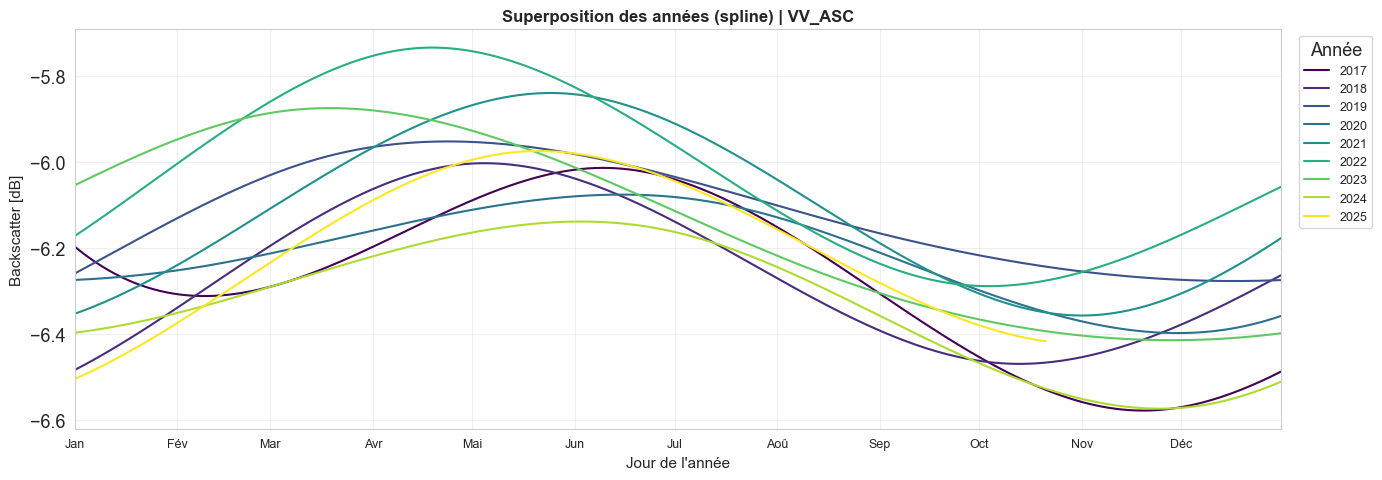

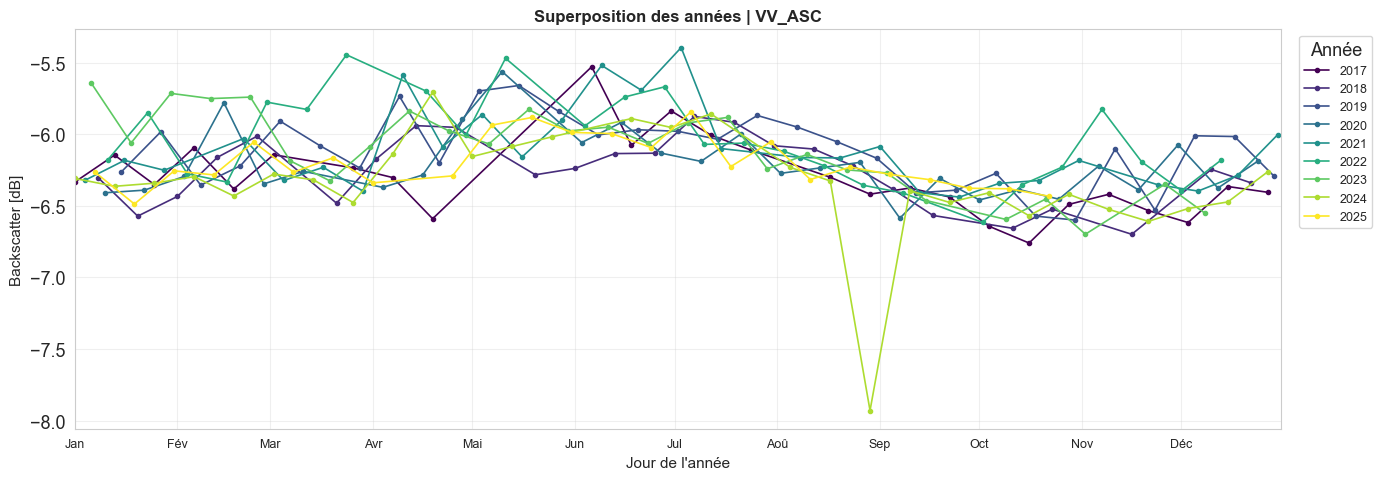

In [55]:
plot_superpose_annees_spline(t_numeric, Y_hat, dates, series_to_plot)
plot_superpose_annees(value, date, "VV_ASC")

# Critère de Corrélation Pearson

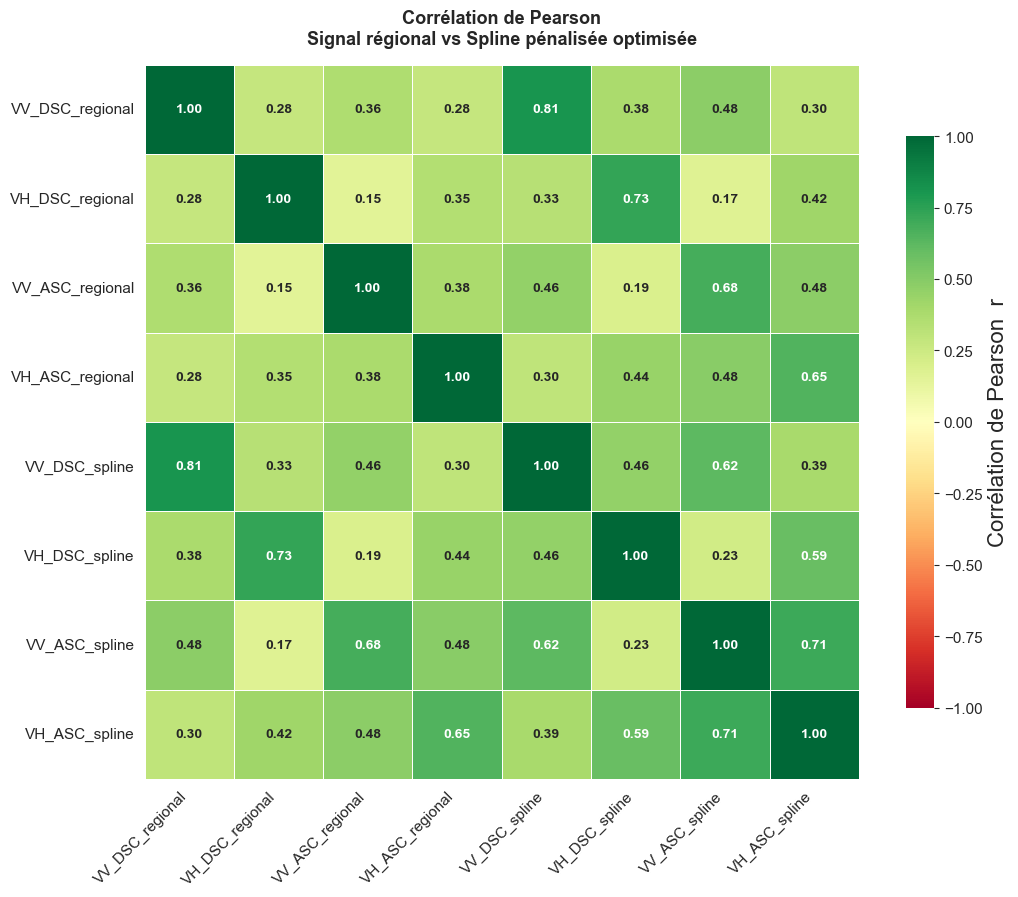

In [56]:
# ════════════════════════════════════════════════════════════
#  PARAMÈTRES
# ════════════════════════════════════════════════════════════
value, date = prepadataframe(1, allROI=1)

series_list = ["VV_DSC", "VH_DSC", "VV_ASC", "VH_ASC"]
roi_index   = 0
alpha       = 3.0

# ════════════════════════════════════════════════════════════
#  CALCUL SIGNAUX ORIGINAUX + SPLINES (régional)
# ════════════════════════════════════════════════════════════

signals = {}
for series in series_list:
    dates        = pd.to_datetime(date[series])
    values_array = value[series]

    if values_array.ndim == 1:
        values_array = values_array[:, np.newaxis]
    roi_idx = min(roi_index, values_array.shape[1] - 1)
    values  = values_array[:, roi_idx]
    t_num   = np.array([(d - dates[0]).days for d in dates], dtype=float)

    n_knots_opt, _ = stepwise_knot_selection_bspline(t_num, values, alpha=alpha, verbose=False)
    B               = build_bspline_basis(t_num, n_knots_opt)
    lam_opt         = optimize_lambda_gcv(B, values)
    _, Y_hat        = penalized_spline_fit(B, values, lam_opt)

    signals[f"{series}_regional"] = values
    signals[f"{series}_spline"]   = Y_hat

# Ordonner : d'abord les 4 regionaux, puis les 4 splines (comme l'image)
ordered_keys = [f"{s}_regional" for s in series_list] + \
               [f"{s}_spline"   for s in series_list]

min_len    = min(len(signals[k]) for k in ordered_keys)
df_signals = pd.DataFrame({k: signals[k][:min_len] for k in ordered_keys})

# ════════════════════════════════════════════════════════════
#  MATRICE DE CORRÉLATION
# ════════════════════════════════════════════════════════════

corr_matrix = df_signals.corr(method="pearson")

# ════════════════════════════════════════════════════════════
#  CORRPLOT
# ════════════════════════════════════════════════════════════

sns.set_style("white")
plt.rcParams.update({"font.size": 11})

fig, ax = plt.subplots(figsize=(11, 9))

sns.heatmap(
    corr_matrix,
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Corrélation de Pearson  r", "shrink": 0.8},
    annot_kws={"size": 10, "weight": "bold"}
)

ax.set_title("Corrélation de Pearson\nSignal régional vs Spline pénalisée optimisée",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Superposition Splines

In [57]:
print(len(t_numeric), len(Y_hat), len(dates))

243 242 242


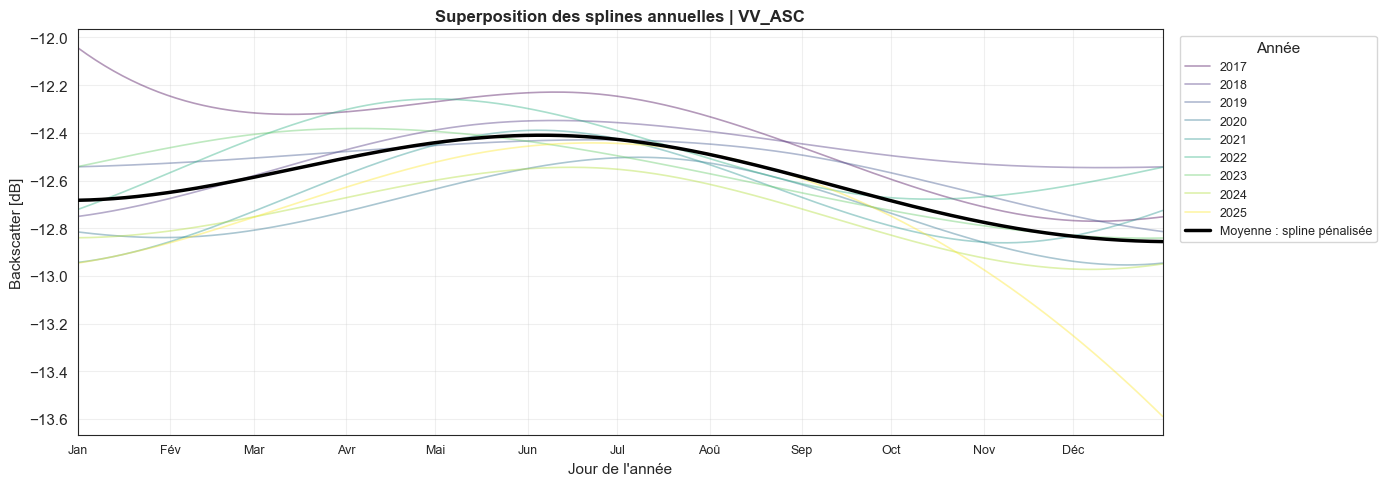

In [58]:
def plot_superpose_annees_spline_moyenne(t_numeric, Y_hat, dates, nom, 
                                         title=None, interpolation='spline'):
    """
    Superpose les années de la spline pénalisée + moyenne annuelle.
    t_numeric : jours depuis la première date
    Y_hat     : valeurs de la spline
    dates     : pd.DatetimeIndex ou liste de datetime
    """
    dates = pd.to_datetime(dates)
    
    n = min(len(t_numeric), len(Y_hat), len(dates))

    df_plot = pd.DataFrame({
        "t":     np.array(t_numeric[:n]),
        "value": np.array(Y_hat[:n]),
        "year":  np.array(dates[:n].year),
        "doy":   np.array(dates[:n].dayofyear),
        })
    years  = sorted(df_plot["year"].unique())
    colors = plt.cm.viridis(np.linspace(0, 1, len(years)))
    doy_grid = np.arange(1, 366)

    fig, ax = plt.subplots(figsize=(14, 5))

    # -- Une courbe par année ----------------------------------------------
    all_year_values = []  # pour calculer la moyenne

    for year, color in zip(years, colors):
        df_year = df_plot[df_plot["year"] == year].sort_values("doy")
        
        if len(df_year) < 4:
            continue

        # Interpolation sur grille journalière pour cette année
        from scipy.interpolate import interp1d
        interp_yr = interp1d(df_year["doy"], df_year["value"],
                             kind='cubic', fill_value="extrapolate")
        y_dense = interp_yr(doy_grid)
        all_year_values.append(y_dense)

        ax.plot(doy_grid, y_dense, linewidth=1.2,
                color=color, alpha=0.4, label=str(year))

    # -- Moyenne des courbes annuelles -------------------------------------
    mean_curve = np.mean(all_year_values, axis=0)  # shape (365,)

    if interpolation == 'linear':
        ax.plot(doy_grid, mean_curve, color="black", linewidth=2.5,
                zorder=5, label="Moyenne : linéaire")

    elif interpolation == 'cubic':
        ax.plot(doy_grid, mean_curve, color="black", linewidth=2.5,
                zorder=5, label="Moyenne : cubique")

    elif interpolation == 'spline':
        B_mean   = build_bspline_basis(doy_grid.astype(float), n_knots=8)
        lam_mean = optimize_lambda_gcv(B_mean, mean_curve)
        _, mean_smooth = penalized_spline_fit(B_mean, mean_curve, lam_mean)
        ax.plot(doy_grid, mean_smooth, color="black", linewidth=2.5,
                zorder=5, label="Moyenne : spline pénalisée")

    ax.set_xlabel("Jour de l'année", fontsize=11)
    ax.set_ylabel("Backscatter [dB]", fontsize=11)
    ax.set_title(title or f"Superposition des splines annuelles | {nom}",
                 fontsize=12, fontweight="bold")
    ax.set_xlim(1, 365)
    ax.set_xticks([1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335])
    ax.set_xticklabels(["Jan","Fév","Mar","Avr","Mai","Jun",
                        "Jul","Aoû","Sep","Oct","Nov","Déc"], fontsize=9)
    ax.legend(title="Année", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Appel
plot_superpose_annees_spline_moyenne(t_numeric, Y_hat, dates, 
                                     series_to_plot, interpolation='spline')

# Regression Locale

In [59]:
# masked = défoilié
# régional => non défoliées et données défoliées => locale 

# la série temporelle choisie
series_to_plot   = "VV_ASC"
series_to_plot_loc= "VV_DEFOL"
roi_index_local  = 0

# Choix de la Série Régionale

value_paracou, date_source_paracou = prepadataframe(1, 1) # version Paracou

value_trinit_1, value_trinit_2, date_source_trinit = prepadataframe(0, 1) # version Trinité
value_source = value_trinit_1
date_source = date_source_trinit

# Choix de la Série Locale

value_paracou_loc, date_source_loc_paracou = prepadataframe(1, 0) # version Paracou

value_trinit_loc_1, value_trinit_loc_2, date_source_loc_trinit = prepadataframe(0, 0) # version Trinité
value_source_loc = value_trinit_loc_2
date_source_loc = date_source_loc_trinit

# "optimal" → sélection automatique par Mallows Cp ou le nombre de points de la série temporelle
n_knots_mode   = "entier"        # "optimal" | entier

Série : VV_ASC  |  ROI index : 0  |  n = 262
Sélection du nombre de nœuds (alpha=3.0) ...

   # nœuds   p=nœuds+4             RSS              Cp
  ------------------------------------------------------
        87          91          4.7441         12.3180  ← modèle initial
        86          90          4.7644         12.2551  ← optimal
        85          89          4.7120         12.1194  ← optimal
        84          88          4.7221         12.0463  ← optimal
        83          87          4.7635         12.0045  ← optimal
        82          86          4.6790         11.8368  ← optimal
        81          85          4.7247         11.7992  ← optimal
        80          84          4.7251         11.7163  ← optimal
        79          83          4.7750         11.6831  ← optimal
        78          82          4.7056         11.5304  ← optimal
        77          81          4.7299         11.4715  ← optimal
        76          80          4.7713         11.4296  ← optima

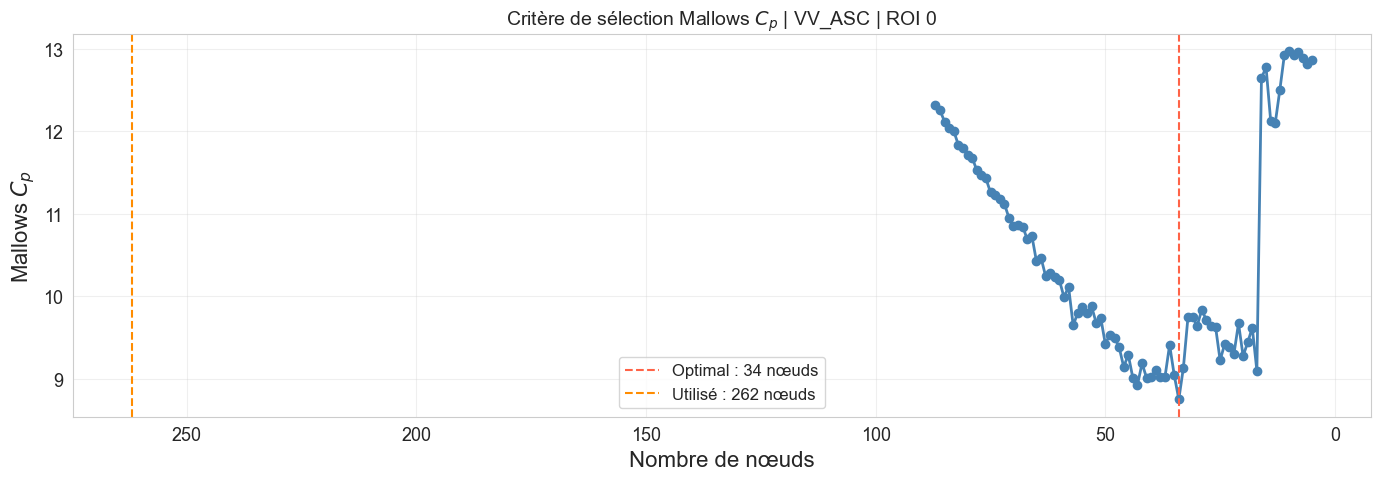

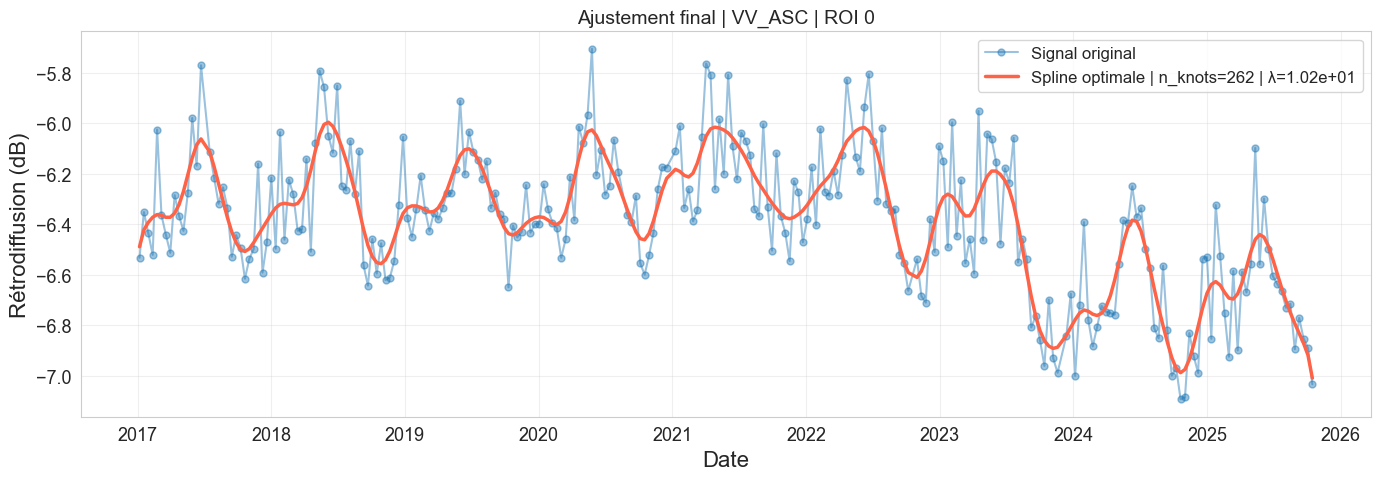

In [60]:
# ════════════════════════════════════════════════════════════
#  PARAMÈTRES | à modifier ici uniquement
# ════════════════════════════════════════════════════════════
alpha          = 3.0              # paramètre Mallows Cp (3=Kooperberg, 2=AIC, log(n)=BIC)

# ════════════════════════════════════════════════════════════
#  PRÉPARATION DES DONNÉES
# ════════════════════════════════════════════════════════════

dates = pd.to_datetime(date_source[series_to_plot])
values_array = value_source[series_to_plot]
if values_array.ndim == 1:
    values_array = values_array[:, np.newaxis]
roi_idx = min(roi_index, values_array.shape[1] - 1)
values  = values_array[:, roi_idx]

t_numeric = np.array([(d - dates[0]).days for d in dates], dtype=float)

# ════════════════════════════════════════════════════════════
#  SÉLECTION DU NOMBRE DE NŒUDS
# ════════════════════════════════════════════════════════════

print(f"Série : {series_to_plot}  |  ROI index : {roi_idx}  |  n = {len(values)}")

# Toujours calculer l'optimal pour afficher le graphe Cp
print(f"Sélection du nombre de nœuds (alpha={alpha}) ...\n")
n_knots_optimal, history = stepwise_knot_selection_bspline(t_numeric, values, alpha=alpha)

# Résolution du nombre de nœuds effectif
if n_knots_mode == "optimal":
    n_knots_reg = n_knots_optimal
else:
    n_knots_reg = len(values_array)

print(f"\n  n_knots_mode  : {n_knots_mode}  →  n_knots utilisé = {n_knots_reg}")

# ════════════════════════════════════════════════════════════
#  AJUSTEMENT FINAL
# ════════════════════════════════════════════════════════════

B        = build_bspline_basis(t_numeric, n_knots_reg)
lam_opt  = optimize_lambda_gcv(B, values)
_, Y_hat = penalized_spline_fit(B, values, lam_opt)

# ════════════════════════════════════════════════════════════
#  VISUALISATION | graphe 1 : critère Cp
# ════════════════════════════════════════════════════════════

sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 13, "axes.titlesize": 14, "legend.fontsize": 12})

plt.figure(figsize=(14, 5))
plt.plot(history["n_knots"], history["Cp"], "o-", color="steelblue", linewidth=2)
plt.axvline(n_knots_optimal, color="tomato", linestyle="--",
            label=f"Optimal : {n_knots_optimal} nœuds")
if n_knots_mode != "optimal":
    plt.axvline(n_knots_reg, color="darkorange", linestyle="--",
                label=f"Utilisé : {n_knots_reg} nœuds")
plt.xlabel("Nombre de nœuds")
plt.ylabel("Mallows $C_p$")
plt.title(f"Critère de sélection Mallows $C_p$ | {series_to_plot} | ROI {roi_idx}")
plt.gca().invert_xaxis()
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════
#  VISUALISATION | graphe 2 : ajustement final
# ════════════════════════════════════════════════════════════
plt.figure(figsize=(14, 5))
plt.plot(dates, values, '-o', color='tab:blue', alpha=0.45,
         linewidth=1.5, markersize=5, label="Signal original")
plt.plot(dates, Y_hat, color='tomato', linewidth=2.5,
         label=f"Spline optimale | n_knots={n_knots_reg} | λ={lam_opt:.2e}")
plt.xlabel("Date")
plt.ylabel("Rétrodiffusion (dB)")
plt.title(f"Ajustement final | {series_to_plot} | ROI {roi_idx}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


  n_points      : 262
  n_knots_mode  : entier  →  n_knots_loc = 262
  σ_reg         : 0.2805 dB
  σ_loc         : 1.2069 dB
  σ_loc / σ_reg : 4.3021
  λ_reg         : 1.0235e+01
  λ_local       : 1.8944e+02


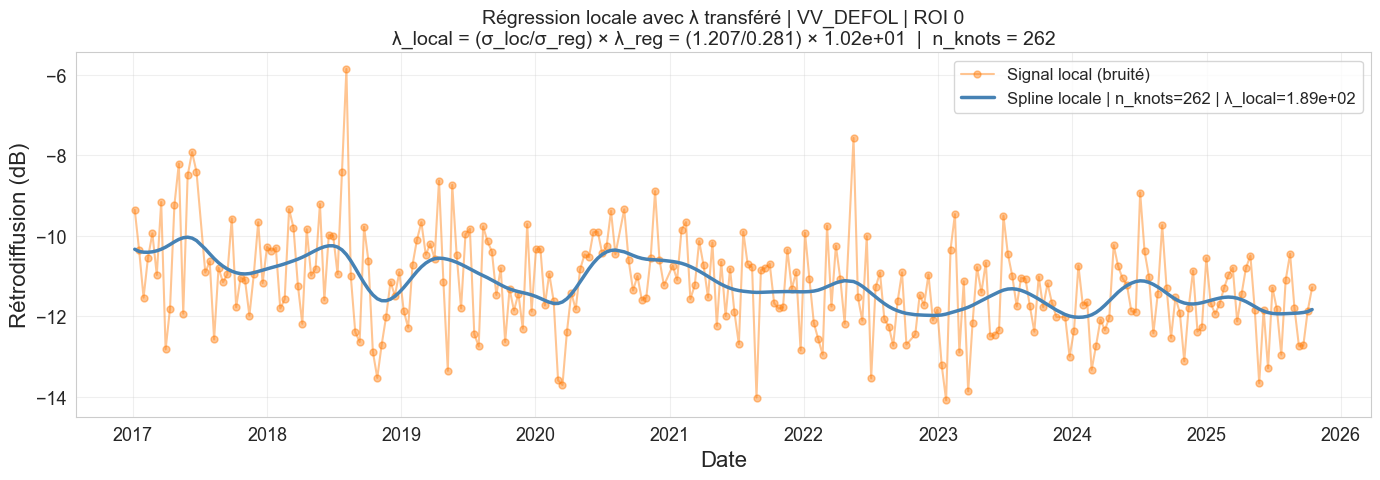

In [61]:
# ════════════════════════════════════════════════════════════
#  PRÉPARATION DES DONNÉES LOCALES
# ════════════════════════════════════════════════════════════
series_to_plot=series_to_plot_loc

dates_loc        = pd.to_datetime(date_source_loc[series_to_plot])
values_array_loc = value_source_loc[series_to_plot]
if values_array_loc.ndim == 1:
    values_array_loc = values_array_loc[:, np.newaxis]
roi_idx_loc = min(roi_index_local, values_array_loc.shape[1] - 1)
values_loc  = values_array_loc[:, roi_idx_loc]

n_loc = len(values_loc)

# -- Résolution du nombre de nœuds ------------------------
if n_knots_mode == "optimal":
    n_knots_loc = n_knots_optimal
elif n_knots_mode == "entier":
    n_knots_loc = n_loc


print(f"  n_points      : {n_loc}")
print(f"  n_knots_mode  : {n_knots_mode}  →  n_knots_loc = {n_knots_loc}")

# ════════════════════════════════════════════════════════════
#  TRANSFERT DE λ
# ════════════════════════════════════════════════════════════

std_reg = np.std(values)
std_loc = np.std(values_loc)
lam_loc = (std_loc / std_reg)**(2) * lam_opt
#lam_loc = ((std_reg-std_loc )/ std_loc) * lam_opt
print(f"  σ_reg         : {std_reg:.4f} dB")
print(f"  σ_loc         : {std_loc:.4f} dB")
print(f"  σ_loc / σ_reg : {std_loc / std_reg:.4f}")
print(f"  λ_reg         : {lam_opt:.4e}")
print(f"  λ_local       : {lam_loc:.4e}")

# ════════════════════════════════════════════════════════════
#  AJUSTEMENT LOCAL
# ════════════════════════════════════════════════════════════

t_loc        = np.array([(d - dates_loc[0]).days for d in dates_loc], dtype=float)
B_loc        = build_bspline_basis(t_loc, n_knots_loc)
_, Y_hat_loc = penalized_spline_fit(B_loc, values_loc, lam_loc)

# ════════════════════════════════════════════════════════════
#  VISUALISATION
# ════════════════════════════════════════════════════════════

plt.figure(figsize=(14, 5))
plt.plot(dates_loc, values_loc, '-o', color='tab:orange', alpha=0.45,
         linewidth=1.5, markersize=5, label="Signal local (bruité)")
plt.plot(dates_loc, Y_hat_loc, color='steelblue', linewidth=2.5,
         label=f"Spline locale | n_knots={n_knots_loc} | λ_local={lam_loc:.2e}")
plt.xlabel("Date")
plt.ylabel("Rétrodiffusion (dB)")
plt.title(f"Régression locale avec λ transféré | {series_to_plot} | ROI {roi_idx_loc}\n"
          f"λ_local = (σ_loc/σ_reg) × λ_reg = ({std_loc:.3f}/{std_reg:.3f}) × {lam_opt:.2e}"
          f"  |  n_knots = {n_knots_loc}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Méthode Régionale sur Zone Locale Défoliée

In [62]:
# masked = défoilié
# régional => non défoliées et données défoliées => locale 

# la série temporelle choisie
series_to_plot   = "VV_DEFOL"
series_to_plot_loc= "VV_DEFOL"
roi_index_local  = 0


# Choix de la Série Locale

value_paracou_loc, date_source_loc_paracou = prepadataframe(1, 0) # version Paracou

value_trinit_loc_1, value_trinit_loc_2, date_source_loc_trinit = prepadataframe(0, 0) # version Trinité

value_source_loc = value_trinit_loc_2
date_source_loc = date_source_loc_trinit

value_source = value_trinit_loc_2
date_source = date_source_loc_trinit

# "optimal" → sélection automatique par Mallows Cp ou le nombre de points de la série temporelle
n_knots_mode   = "entier"        # "optimal" | entier

Série : VV_DEFOL  |  ROI index : 0  |  n = 262
Sélection du nombre de nœuds (alpha=3.0) ...

   # nœuds   p=nœuds+4             RSS              Cp
  ------------------------------------------------------
        87          91        335.1996        870.3429  ← modèle initial
        86          90        335.2714        864.5339  ← optimal
        85          89        335.3433        858.7252  ← optimal
        84          88        335.4155        852.9167  ← optimal
        83          87        335.4880        847.1085  ← optimal
        82          86        335.5607        841.3005  ← optimal
        81          85        335.6337        835.4928  ← optimal
        80          84        335.7069        829.6853  ← optimal
        79          83        335.7802        823.8779  ← optimal
        78          82        335.8537        818.0707  ← optimal
        77          81        335.9273        812.2636  ← optimal
        76          80        336.0010        806.4567  ← opti

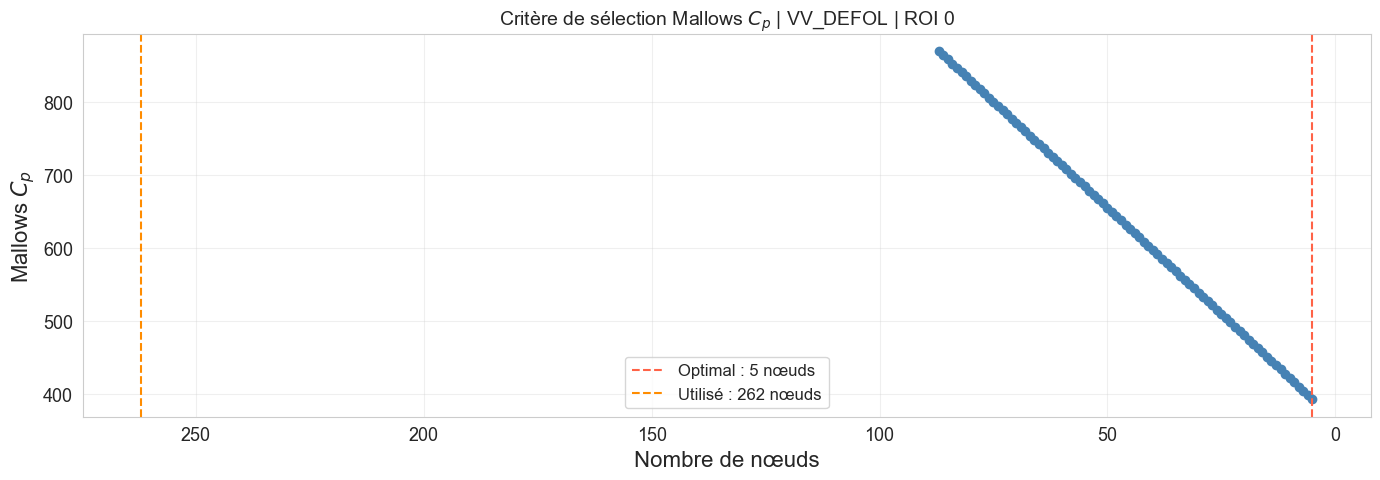

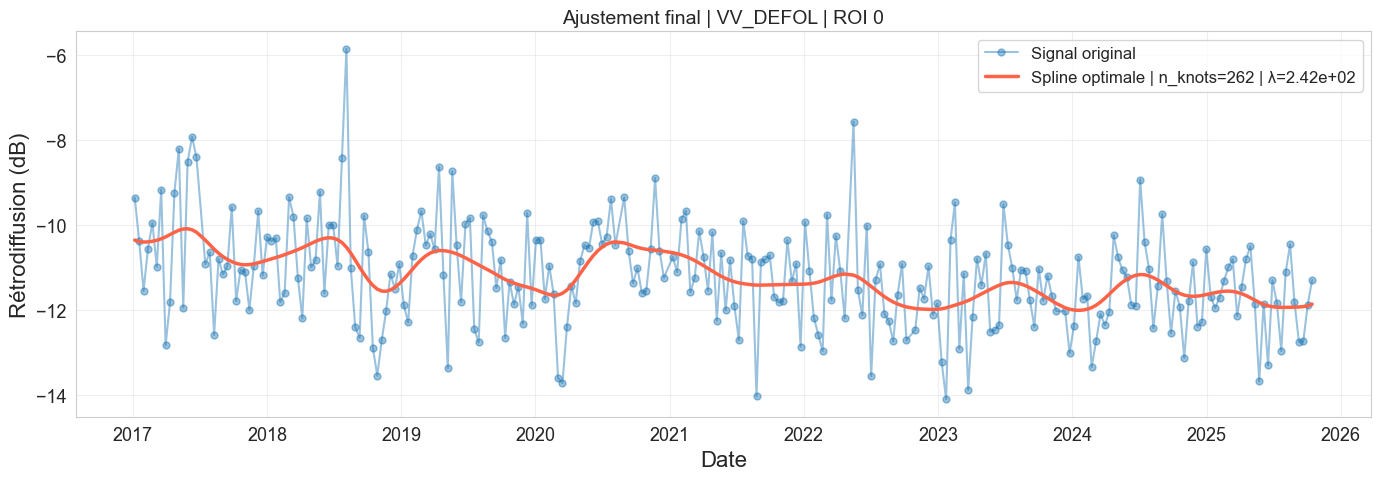

In [63]:
# ════════════════════════════════════════════════════════════
#  PARAMÈTRES | à modifier ici uniquement
# ════════════════════════════════════════════════════════════
alpha          = 3.0              # paramètre Mallows Cp (3=Kooperberg, 2=AIC, log(n)=BIC)

# ════════════════════════════════════════════════════════════
#  PRÉPARATION DES DONNÉES
# ════════════════════════════════════════════════════════════

dates = pd.to_datetime(date_source[series_to_plot])
values_array = value_source[series_to_plot]
if values_array.ndim == 1:
    values_array = values_array[:, np.newaxis]
roi_idx = min(roi_index, values_array.shape[1] - 1)
values  = values_array[:, roi_idx]

t_numeric = np.array([(d - dates[0]).days for d in dates], dtype=float)

# ════════════════════════════════════════════════════════════
#  SÉLECTION DU NOMBRE DE NŒUDS
# ════════════════════════════════════════════════════════════

print(f"Série : {series_to_plot}  |  ROI index : {roi_idx}  |  n = {len(values)}")

# Toujours calculer l'optimal pour afficher le graphe Cp
print(f"Sélection du nombre de nœuds (alpha={alpha}) ...\n")
n_knots_optimal, history = stepwise_knot_selection_bspline(t_numeric, values, alpha=alpha)

# Résolution du nombre de nœuds effectif
if n_knots_mode == "optimal":
    n_knots_reg = n_knots_optimal
else:
    n_knots_reg = len(values_array)

print(f"\n  n_knots_mode  : {n_knots_mode}  →  n_knots utilisé = {n_knots_reg}")

# ════════════════════════════════════════════════════════════
#  AJUSTEMENT FINAL
# ════════════════════════════════════════════════════════════

B        = build_bspline_basis(t_numeric, n_knots_reg)
lam_opt  = optimize_lambda_gcv(B, values)
_, Y_hat = penalized_spline_fit(B, values, lam_opt)

# ════════════════════════════════════════════════════════════
#  VISUALISATION | graphe 1 : critère Cp
# ════════════════════════════════════════════════════════════

sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 13, "axes.titlesize": 14, "legend.fontsize": 12})

plt.figure(figsize=(14, 5))
plt.plot(history["n_knots"], history["Cp"], "o-", color="steelblue", linewidth=2)
plt.axvline(n_knots_optimal, color="tomato", linestyle="--",
            label=f"Optimal : {n_knots_optimal} nœuds")
if n_knots_mode != "optimal":
    plt.axvline(n_knots_reg, color="darkorange", linestyle="--",
                label=f"Utilisé : {n_knots_reg} nœuds")
plt.xlabel("Nombre de nœuds")
plt.ylabel("Mallows $C_p$")
plt.title(f"Critère de sélection Mallows $C_p$ | {series_to_plot} | ROI {roi_idx}")
plt.gca().invert_xaxis()
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════
#  VISUALISATION | graphe 2 : ajustement final
# ════════════════════════════════════════════════════════════
plt.figure(figsize=(14, 5))
plt.plot(dates, values, '-o', color='tab:blue', alpha=0.45,
         linewidth=1.5, markersize=5, label="Signal original")
plt.plot(dates, Y_hat, color='tomato', linewidth=2.5,
         label=f"Spline optimale | n_knots={n_knots_reg} | λ={lam_opt:.2e}")
plt.xlabel("Date")
plt.ylabel("Rétrodiffusion (dB)")
plt.title(f"Ajustement final | {series_to_plot} | ROI {roi_idx}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

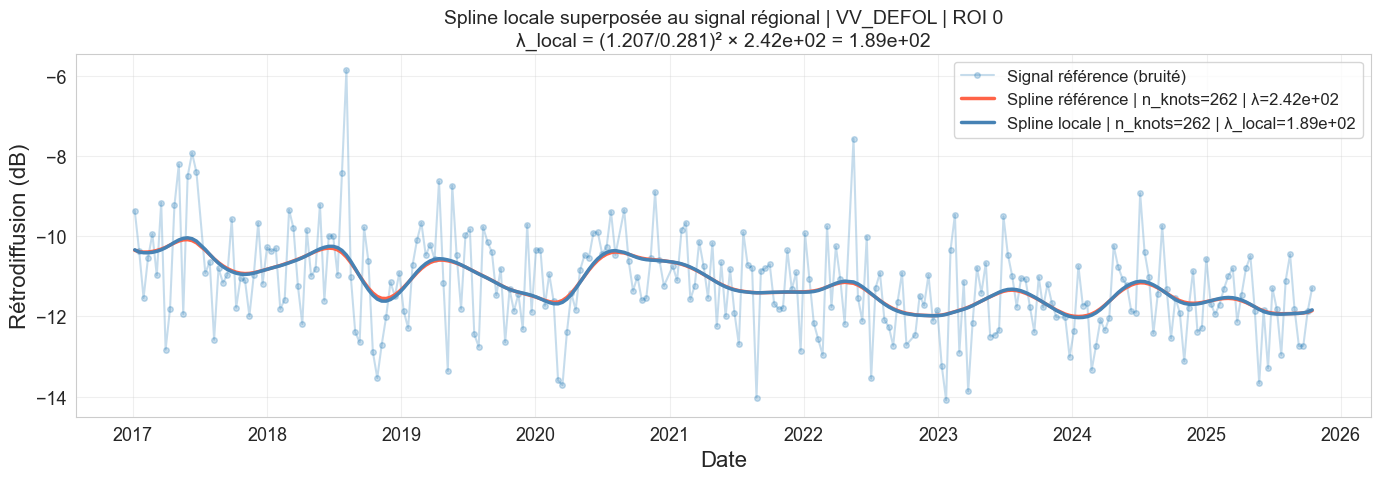

In [64]:
plt.figure(figsize=(14, 5))

# -- Signal + spline régionale (au complet) ------------------------------------
plt.plot(dates, values, '-o', color='tab:blue', alpha=0.25,
         linewidth=1.5, markersize=4, label="Signal référence (bruité)")
plt.plot(dates, Y_hat, color='tomato', linewidth=2.5,
         label=f"Spline référence | n_knots={n_knots_reg} | λ={lam_opt:.2e}")

# -- Spline locale uniquement (pas le signal bruité) ---------------------------
plt.plot(dates_loc, Y_hat_loc, color='steelblue', linewidth=2.5,
         label=f"Spline locale | n_knots={n_knots_loc} | λ_local={lam_loc:.2e}")

plt.xlabel("Date")
plt.ylabel("Rétrodiffusion (dB)")
plt.title(f"Spline locale superposée au signal régional | {series_to_plot} | ROI {roi_idx_loc}\n"
          f"λ_local = ({std_loc:.3f}/{std_reg:.3f})² × {lam_opt:.2e} = {lam_loc:.2e}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Données météo 

## Lecture des données

In [65]:


# -- Chargement -----------------------------------------------------------------
METEO_FILE = "data/Data/Meteo_GX/vw2d-prcp-vpd-T55-30_2016-2024.csv"

df = pd.read_csv(
    METEO_FILE,
    sep=";",
    parse_dates=["#TIMESTAMP"],
    dayfirst=True,
    decimal=".",
)
df = df.rename(columns={
    "#TIMESTAMP": "ts",
    "Dir vent":   "dir_vent",
    "Vit vent":   "vit_vent",
    "Pluie":      "pluie",
    "vpd (55m)":  "vpd",
    "Temp(55)":   "temp55",
    "Temp(30)":   "temp30",
}).set_index("ts")



### Visualisation Générale 

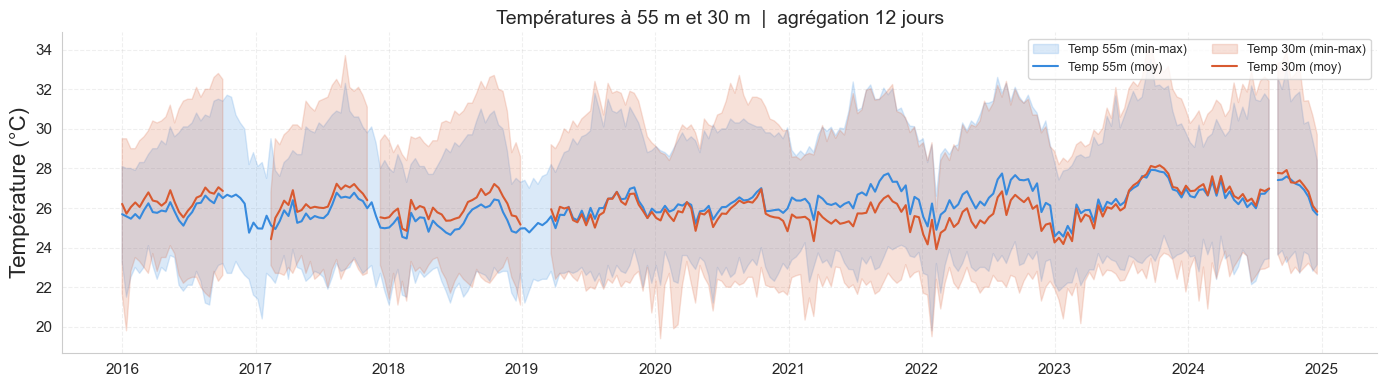

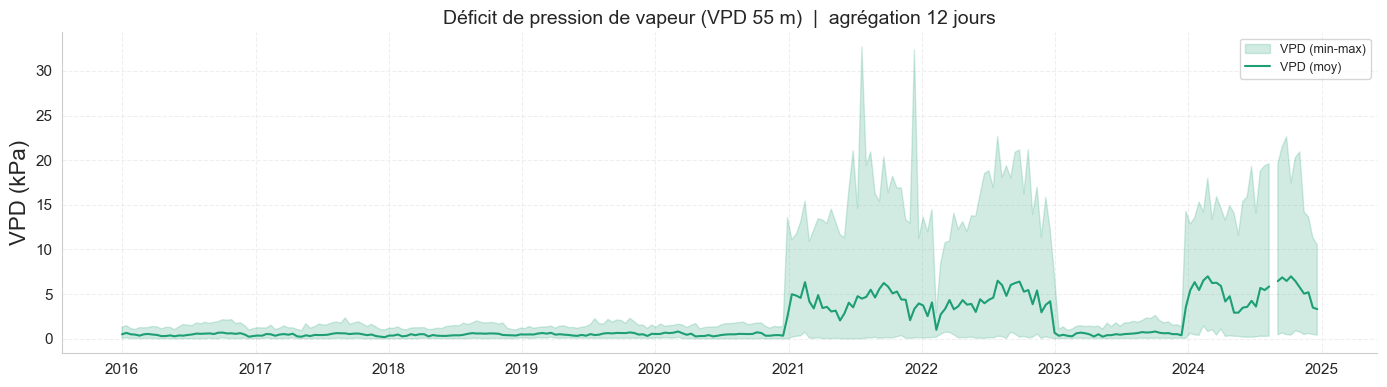

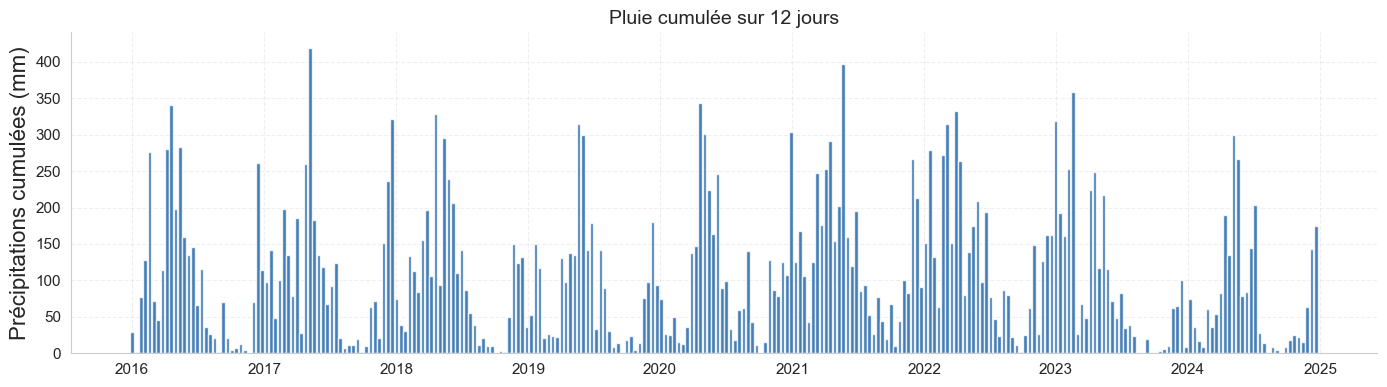

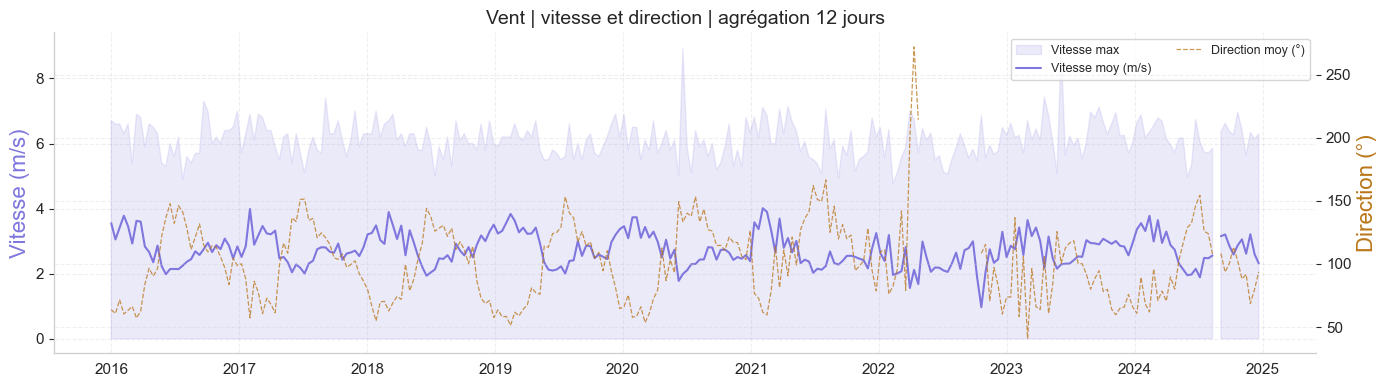

In [66]:
# -- Agrégation 12 jours --------------------------------------------------------
agg = df.resample("12D").agg({
    "temp55":   ["mean", "min", "max"],
    "temp30":   ["mean", "min", "max"],
    "vpd":      ["mean", "min", "max"],
    "pluie":    "sum",
    "vit_vent": ["mean", "max"],
    "dir_vent": "mean",
})
agg.columns = ["_".join(c) for c in agg.columns]
t = agg.index

# -- Style commun ---------------------------------------------------------------
plt.rcParams.update({
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "font.size":         11,
})

def style_xaxis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.set_xlabel("")

# -- 1. Températures ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(t, agg["temp55_min"], agg["temp55_max"],
                alpha=0.18, color="#378ADD", label="Temp 55m (min-max)")
ax.plot(t, agg["temp55_mean"], color="#378ADD", lw=1.5, label="Temp 55m (moy)")
ax.fill_between(t, agg["temp30_min"], agg["temp30_max"],
                alpha=0.18, color="#D85A30", label="Temp 30m (min-max)")
ax.plot(t, agg["temp30_mean"], color="#D85A30", lw=1.5, label="Temp 30m (moy)")
ax.set_ylabel("Température (°C)")
ax.set_title("Températures à 55 m et 30 m  |  agrégation 12 jours")
ax.legend(fontsize=9, ncol=2)
style_xaxis(ax)
plt.tight_layout()
plt.show()

# -- 2. VPD ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(t, agg["vpd_min"], agg["vpd_max"],
                alpha=0.2, color="#1D9E75", label="VPD (min-max)")
ax.plot(t, agg["vpd_mean"], color="#1D9E75", lw=1.5, label="VPD (moy)")
ax.set_ylabel("VPD (kPa)")
ax.set_title("Déficit de pression de vapeur (VPD 55 m)  |  agrégation 12 jours")
ax.legend(fontsize=9)
style_xaxis(ax)
plt.tight_layout()
plt.show()

# -- 3. Pluie -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(t, agg["pluie_sum"], width=10, color="#185FA5", alpha=0.8)
ax.set_ylabel("Précipitations cumulées (mm)")
ax.set_title("Pluie cumulée sur 12 jours")
style_xaxis(ax)
plt.tight_layout()
plt.show()

# -- 4. Vent --------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()
ax1.fill_between(t, 0, agg["vit_vent_max"],
                 alpha=0.15, color="#7F77DD", label="Vitesse max")
ax1.plot(t, agg["vit_vent_mean"], color="#7F77DD", lw=1.5, label="Vitesse moy (m/s)")
ax2.plot(t, agg["dir_vent_mean"], color="#BA7517", lw=0.9,
         linestyle="--", alpha=0.75, label="Direction moy (°)")
ax1.set_ylabel("Vitesse (m/s)", color="#7F77DD")
ax2.set_ylabel("Direction (°)", color="#BA7517")
ax1.set_title("Vent | vitesse et direction | agrégation 12 jours")
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labs  = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labs, fontsize=9, ncol=2)
style_xaxis(ax1)
plt.tight_layout()
plt.show()

### Superposition sur une année

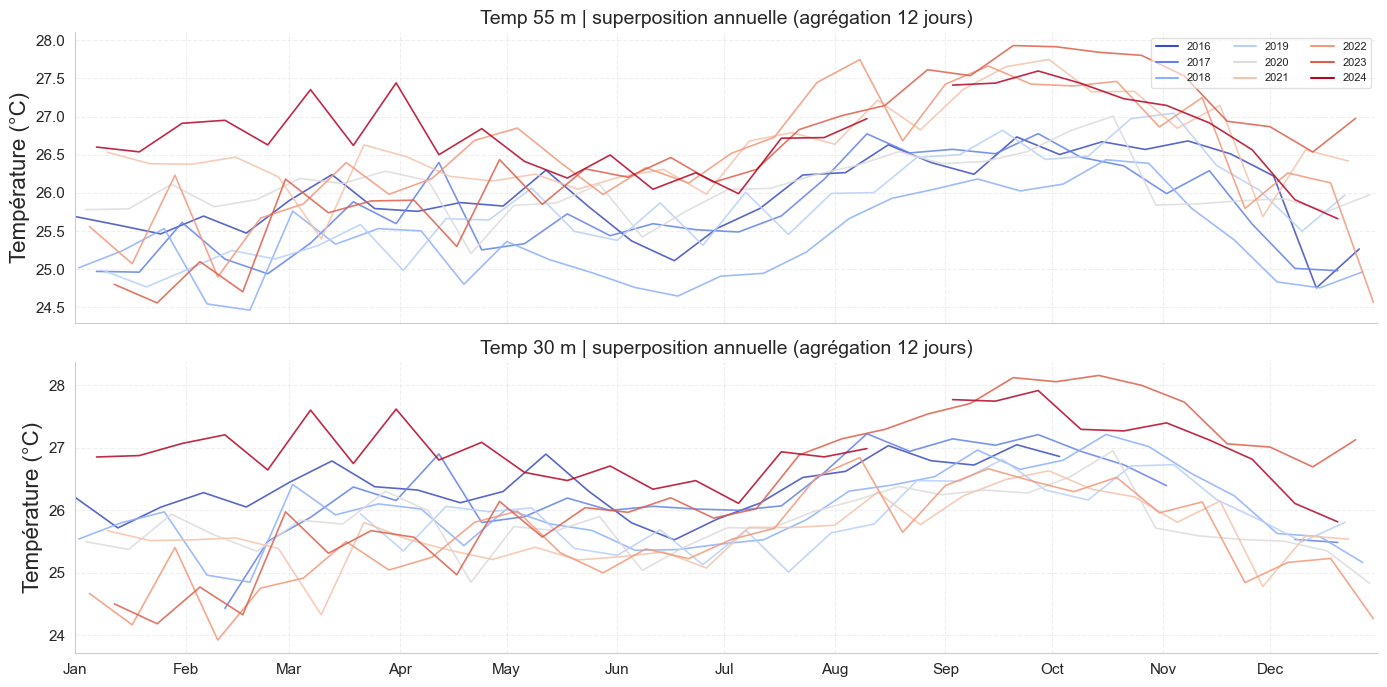

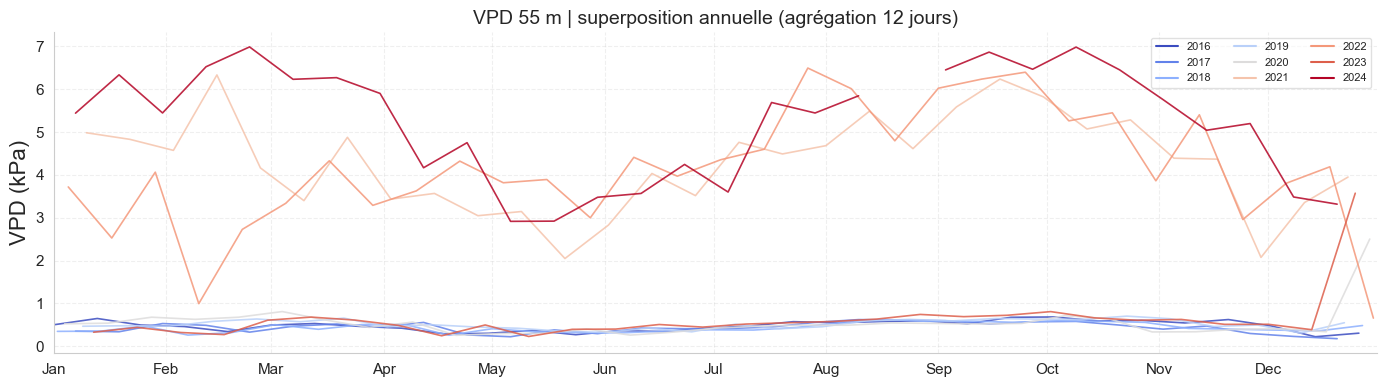

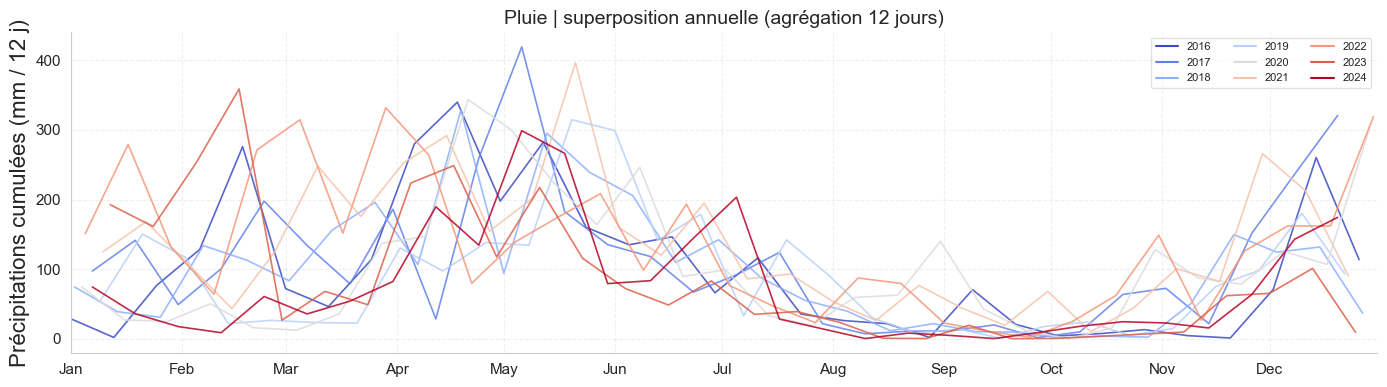

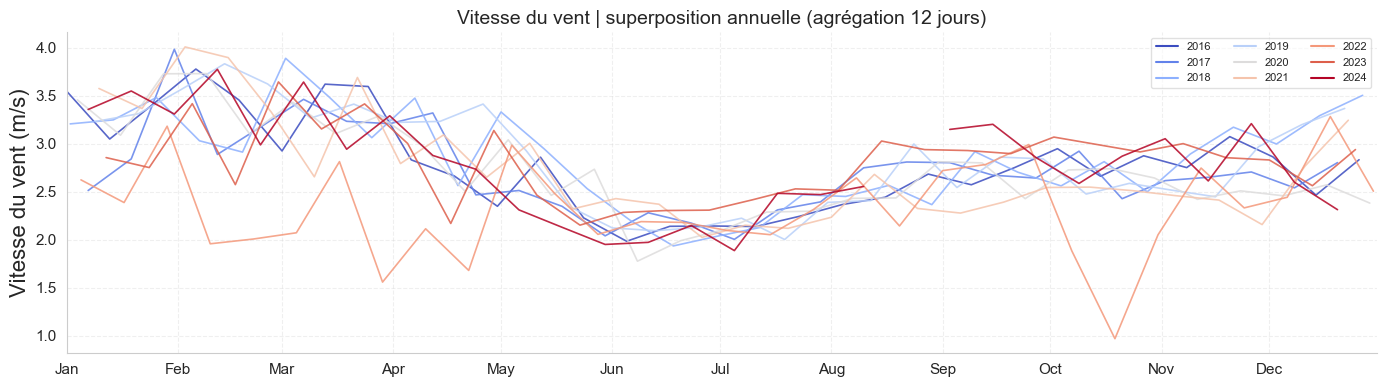

In [67]:

agg = df.resample("12D").agg({
    "temp55":   "mean",
    "temp30":   "mean",
    "vpd":      "mean",
    "pluie":    "sum",
    "vit_vent": "mean",
    "dir_vent": "mean",
})
# PAS de agg.columns = ["_".join(c) ...] ici, on garde les noms simples
agg["doy"]  = agg.index.day_of_year
agg["year"] = agg.index.year

YEARS = sorted(agg["year"].unique())

# Référence fictive sur 2000 pour l'axe X (année non bissextile → 365 j)
def doy_to_date(doy):
    return pd.Timestamp("2000-01-01") + pd.to_timedelta(doy - 1, unit="D")

# Palette : dégradé bleu→rouge sur le nombre d'années
cmap   = plt.cm.coolwarm
colors = {y: cmap(i / (len(YEARS) - 1)) for i, y in enumerate(YEARS)}

# -- Style commun ---------------------------------------------------------------
plt.rcParams.update({
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "font.size":         11,
})

def style_xaxis(ax):
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.set_xlim(pd.Timestamp("2000-01-01"), pd.Timestamp("2000-12-31"))
    ax.set_xlabel("")

def add_legend(ax):
    handles = [plt.Line2D([0], [0], color=colors[y], lw=1.5, label=str(y))
               for y in YEARS]
    ax.legend(handles=handles, fontsize=8, ncol=3,
              loc="upper right", framealpha=0.6)

# -- 1. Températures 55m --------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for y in YEARS:
    sub = agg[agg["year"] == y].copy()
    x   = sub["doy"].apply(doy_to_date)
    axes[0].plot(x, sub["temp55"], color=colors[y], lw=1.2, alpha=0.85)
    axes[1].plot(x, sub["temp30"], color=colors[y], lw=1.2, alpha=0.85)

axes[0].set_ylabel("Température (°C)")
axes[0].set_title("Temp 55 m | superposition annuelle (agrégation 12 jours)")
axes[1].set_ylabel("Température (°C)")
axes[1].set_title("Temp 30 m | superposition annuelle (agrégation 12 jours)")
add_legend(axes[0])
style_xaxis(axes[1])
plt.tight_layout()
plt.show()

# -- 2. VPD ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 4))
for y in YEARS:
    sub = agg[agg["year"] == y].copy()
    x   = sub["doy"].apply(doy_to_date)
    ax.plot(x, sub["vpd"], color=colors[y], lw=1.2, alpha=0.85)
ax.set_ylabel("VPD (kPa)")
ax.set_title("VPD 55 m | superposition annuelle (agrégation 12 jours)")
add_legend(ax)
style_xaxis(ax)
plt.tight_layout()
plt.show()

# -- 3. Pluie -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 4))
for y in YEARS:
    sub = agg[agg["year"] == y].copy()
    x   = sub["doy"].apply(doy_to_date)
    ax.plot(x, sub["pluie"], color=colors[y], lw=1.2, alpha=0.85)
ax.set_ylabel("Précipitations cumulées (mm / 12 j)")
ax.set_title("Pluie | superposition annuelle (agrégation 12 jours)")
add_legend(ax)
style_xaxis(ax)
plt.tight_layout()
plt.show()

# -- 4. Vent --------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 4))
for y in YEARS:
    sub = agg[agg["year"] == y].copy()
    x   = sub["doy"].apply(doy_to_date)
    ax.plot(x, sub["vit_vent"], color=colors[y], lw=1.2, alpha=0.85)
ax.set_ylabel("Vitesse du vent (m/s)")
ax.set_title("Vitesse du vent | superposition annuelle (agrégation 12 jours)")
add_legend(ax)
style_xaxis(ax)
plt.tight_layout()
plt.show()

## Pluie sur les grahes

t : 2016-01-01 00:00:00 → 2024-12-20 00:00:00
dates_loc : 2017-01-06 00:00:00 → 2025-10-15 00:00:00
Points dans la fenêtre : 243
t_filtered : 243 points
pluie_filtered : 243 points, sum=25489.9
pluie_filtered NaN : 0
values_loc range : -14.09 → -5.86
Y_hat_loc range : -12.03 → -10.04


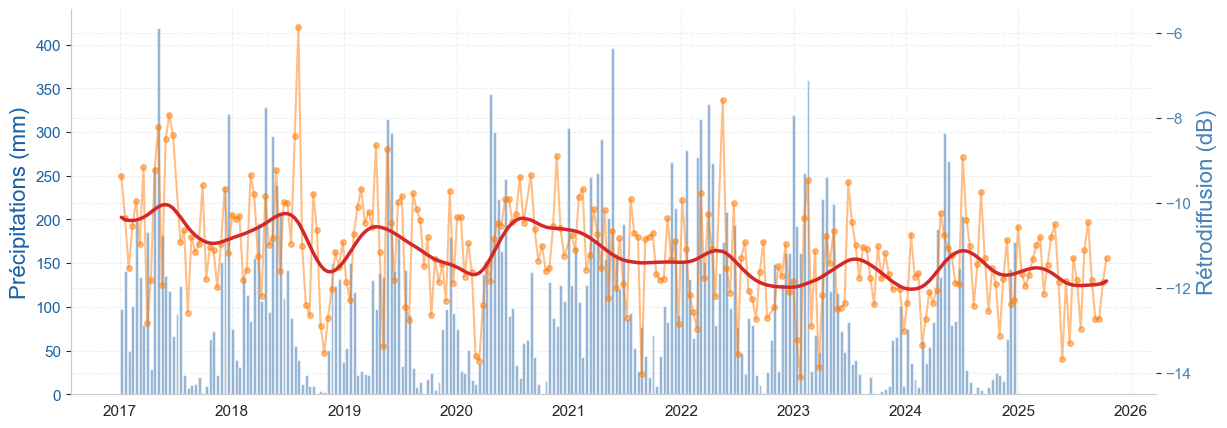

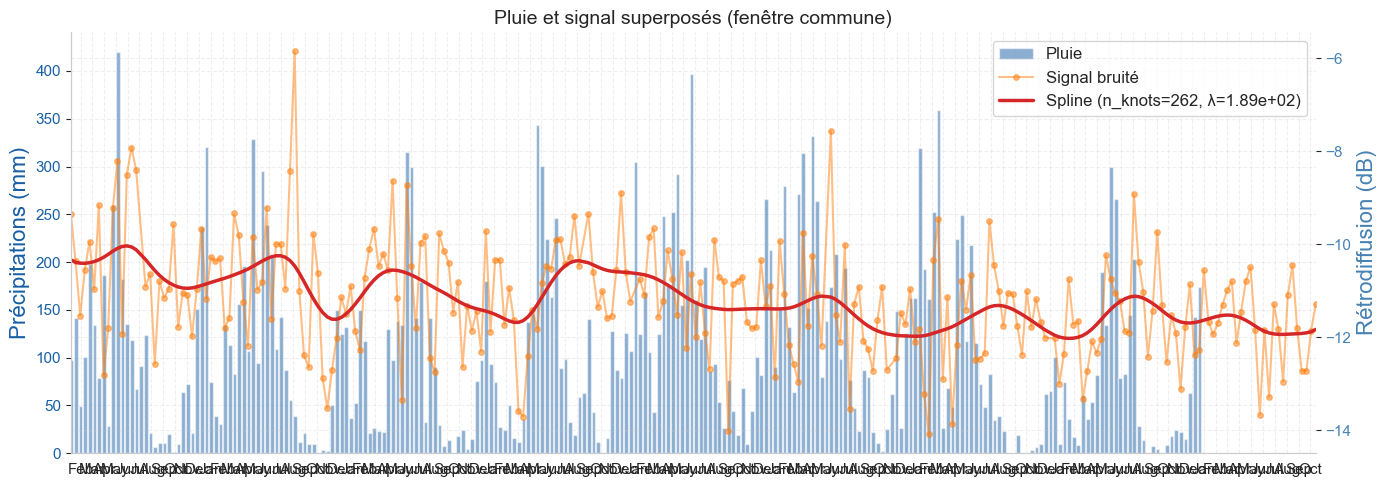

<Figure size 640x480 with 0 Axes>

In [68]:
# ------------------------------------------------------------------------------
# Superposition pluie + signal (fenêtre commune propre)
# ------------------------------------------------------------------------------

# -- Assurer que les dates sont bien en datetime --
t = pd.to_datetime(t)
dates_loc = pd.to_datetime(dates_loc)

# -- Définir la fenêtre temporelle du signal --
start = dates_loc.min()
end = dates_loc.max()

# -- Filtrer la pluie sur cette fenêtre --
print(f"t : {t.min()} → {t.max()}")
print(f"dates_loc : {dates_loc.min()} → {dates_loc.max()}")
print(f"Points dans la fenêtre : {mask.sum()}")
mask = (t >= start) & (t <= end)
t_filtered     = pd.Series(t[mask]).reset_index(drop=True)
pluie_filtered = agg[pluie_col[0]][mask].reset_index(drop=True)

print(f"t_filtered : {len(t_filtered)} points")
print(f"pluie_filtered : {len(pluie_filtered)} points, sum={pluie_filtered.sum():.1f}")
print(f"pluie_filtered NaN : {pluie_filtered.isna().sum()}")
print(f"values_loc range : {values_loc.min():.2f} → {values_loc.max():.2f}")
print(f"Y_hat_loc range : {Y_hat_loc.min():.2f} → {Y_hat_loc.max():.2f}")

# -- Largeur automatique des barres (si données régulières) --
if len(t_filtered) > 1:
    delta_days = (t_filtered[1] - t_filtered[0]).days
    width = pd.Timedelta(days=max(delta_days * 0.8, 0.5))
else:
    width = pd.Timedelta(days=1)

# -- Création du plot --
fig, ax1 = plt.subplots(figsize=(14, 5))

# -- Pluie (axe gauche) --
ax1.bar(t_filtered, pluie_filtered,
        width=width,
        color="#185FA5",
        alpha=0.5,
        label="Pluie")

ax1.set_ylabel("Précipitations (mm)", color="#185FA5")
ax1.tick_params(axis='y', labelcolor="#185FA5")

# -- Signal + spline (axe droit) --
ax2 = ax1.twinx()

ax2.plot(dates_loc, values_loc, '-o',
         color='tab:orange',
         alpha=0.5,
         linewidth=1.5,
         markersize=4,
         label="Signal bruité")

ax2.plot(dates_loc, Y_hat_loc,
         color="#d62728",
         linewidth=2.5,
         label=f"Spline (n_knots={n_knots_loc}, λ={lam_loc:.2e})")

ax2.set_ylabel("Rétrodiffusion (dB)", color="steelblue")
ax2.tick_params(axis='y', labelcolor="steelblue")

# -- Création du plot --
fig, ax1 = plt.subplots(figsize=(14, 5))

# -- Pluie (axe gauche) --
ax1.bar(t_filtered, pluie_filtered,
        width=width,
        color="#185FA5",
        alpha=0.5,
        label="Pluie")
ax1.set_ylabel("Précipitations (mm)", color="#185FA5")
ax1.tick_params(axis='y', labelcolor="#185FA5")

# -- Signal + spline (axe droit) --
ax2 = ax1.twinx()
ax2.plot(dates_loc, values_loc, '-o',
         color='tab:orange',
         alpha=0.5,
         linewidth=1.5,
         markersize=4,
         label="Signal bruité")
ax2.plot(dates_loc, Y_hat_loc,
         color="#d62728",
         linewidth=2.5,
         label=f"Spline (n_knots={n_knots_loc}, λ={lam_loc:.2e})")
ax2.set_ylabel("Rétrodiffusion (dB)", color="steelblue")
ax2.tick_params(axis='y', labelcolor="steelblue")

# -- Mise en forme : style_xaxis AVANT set_xlim --
style_xaxis(ax1)
ax1.set_xlim(pd.Timestamp(start), pd.Timestamp(end))
ax1.set_title("Pluie et signal superposés (fenêtre commune)")
ax1.grid(True, alpha=0.3)

# -- Légende combinée --
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

# -- Légende combinée --
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

## Corrélation entre la pluie et Séries/Spline

In [69]:
# Merge du signal SAR avec les données météo
# On reconstruit ts_local depuis dates_loc et values_loc
ts_local = pd.DataFrame({
    "ts":     pd.to_datetime(dates_loc),
    "signal": values_loc,
}).sort_values("ts").reset_index(drop=True)

df_meteo = df.copy()
df_meteo.index = pd.to_datetime(df_meteo.index)

# merge_asof : associe a chaque date SAR la mesure météo la plus proche
# Les deux côtés doivent être triés par la clé de merge
df_merged = pd.merge_asof(
    ts_local,
    df_meteo.reset_index().sort_values("ts"),
    on="ts",
    direction="nearest"
)

# Merge du signal SAR avec les données météo
ts_local = pd.DataFrame({
    "ts":     pd.to_datetime(dates_loc),
    "signal": values_loc,
}).sort_values("ts").reset_index(drop=True)

df_meteo = df.copy()
df_meteo.index = pd.to_datetime(df_meteo.index)

df_merged = pd.merge_asof(
    ts_local,
    df_meteo.reset_index().sort_values("ts"),
    on="ts",
    direction="nearest"
)

# df et df_merged pointent vers le même objet pour compatibilité avec les cellules suivantes
df = df_merged

print(f"Merge OK : {len(df_merged)} lignes | colonnes : {list(df_merged.columns)}")

Merge OK : 262 lignes | colonnes : ['ts', 'signal', 'dir_vent', 'vit_vent', 'pluie', 'vpd', 'temp55', 'temp30']


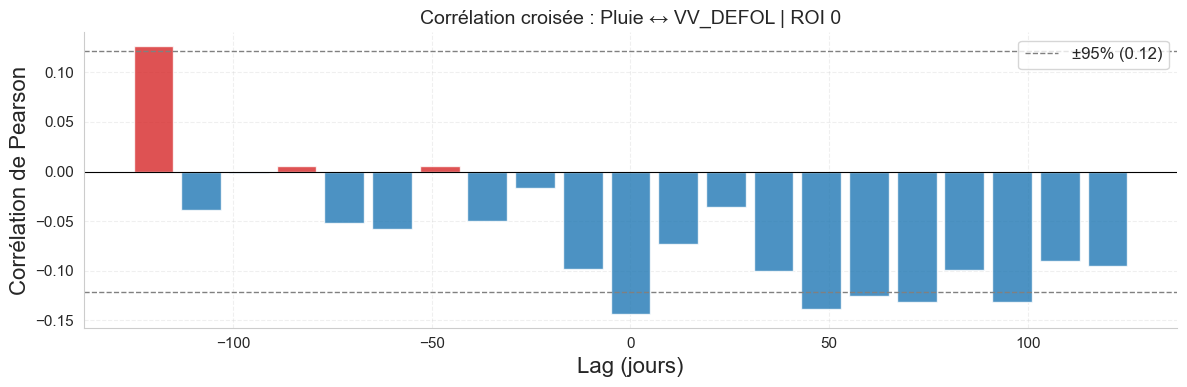

In [70]:
# On supprime toutes les lignes où signal ou pluie est NaN
# (les 25 trous du merge_asof), sinon les tableaux numpy auraient
# des tailles différentes et corrcoef planterait
df_clean = df.dropna(subset=["signal", "pluie"]).reset_index(drop=True)

# Extraction en arrays numpy bruts pour le calcul vectoriel
signal = df_clean["signal"].values
pluie  = df_clean["pluie"].values

# Normalisation Z-score : on centre (- mean) et on réduit (/ std)
# Indispensable pour que corrcoef compare des grandeurs comparables :
# le signal est en dB (~-15 à -5) et la pluie en mm (~0 à 50)
signal_n = (signal - signal.mean()) / signal.std()
pluie_n  = (pluie  - pluie.mean())  / pluie.std()

n = len(signal_n)  # nombre de points communs (~237)
max_lag = 10       # on teste jusqu'à ±10 pas, soit ±120 jours

# np.arange(-10, 11) → [-10, -9, ..., 0, ..., 9, 10]
# 21 lags au total
lags = np.arange(-max_lag, max_lag + 1)

def xcorr(x, y, lag):
    if lag >= 0:
        # lag positif : "la pluie d'il y a `lag` pas prédit-elle le signal ?"
        # x (signal) : on coupe les `lag` derniers  → x[:n-lag]
        # y (pluie)  : on coupe les `lag` premiers  → y[lag:]
        # les deux tranches ont exactement la même longueur : n-lag
        # Exemple lag=2, n=6 :
        #   x : [s1, s2, s3, s4]  (on drop s5,s6)
        #   y : [p3, p4, p5, p6]  (on drop p1,p2)
        return np.corrcoef(x[:n-lag], y[lag:])[0, 1] if n - lag > 1 else np.nan
    else:
        # lag négatif : "le signal d'il y a `|lag|` pas prédit-il la pluie ?"
        # x (signal) : on coupe les `|lag|` premiers → x[-lag:]
        # y (pluie)  : on coupe les `|lag|` derniers → y[:n+lag]
        # lag=-2, n=6 :
        #   x : [s3, s4, s5, s6]  (on drop s1,s2)
        #   y : [p1, p2, p3, p4]  (on drop p5,p6)
        return np.corrcoef(x[-lag:], y[:n+lag])[0, 1] if n + lag > 1 else np.nan

# On appelle xcorr pour chacun des 21 lags → liste de 21 coefficients Pearson
corrs = [xcorr(signal_n, pluie_n, l) for l in lags]

# Seuil de significativité à 95% : tout |corr| > seuil est non-aléatoire
# Formule : 1.96 / sqrt(n), basée sur la distribution de Student pour grandes n
seuil = 1.96 / np.sqrt(n)

# Couleur par signe : rouge = corrélation positive, bleu = négative
colors = ["#d62728" if c > 0 else "#1f77b4" for c in corrs]

fig, ax = plt.subplots(figsize=(12, 4))

# lags * 12 convertit les lags en jours réels (1 pas = 12 jours)
# width=10 < 12 pour laisser un petit espace entre les barres
ax.bar(lags * 12, corrs, width=10, color=colors, alpha=0.8)

ax.axhline(0, color="black", linewidth=0.8)

# Les deux lignes pointillées grises matérialisent le corridor du bruit
ax.axhline( seuil, color="grey", linestyle="--", linewidth=1, label=f"±95% ({seuil:.2f})")
ax.axhline(-seuil, color="grey", linestyle="--", linewidth=1)

# L'axe X est en jours : lag négatif à gauche = signal précède la pluie
#                         lag positif à droite = pluie précède le signal
ax.set_xlabel("Lag (jours)")
ax.set_ylabel("Corrélation de Pearson")
ax.set_title(f"Corrélation croisée : Pluie ↔ {series_to_plot} | ROI {roi_idx_loc}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Nouvelles données 

## Prise en main 

## Modalités disponibles

| Paramètre       | Valeurs possibles                        |
|:----------------|:-----------------------------------------|
| `subzone`       | `1` `2` `3` `4` `5` `6` `7` `8` `9` `10` |
| `type_veg`      | `"fol"` `"defol"` `"nodata"`             |
| `polarization`  | `"vh"` `"vv"`                            |
| `orbite`        | `39` `120`                               |
| `direction`     | `"ASC"` `"DES"`                          |
| `satellite`     | `"s1a"` `"s1b"` `"s1c"`                  |

In [71]:
FILEPATH = "data/Data/StudyCase_S1_Trinité/ts_10subzones_defoliated.csv"

def extract_signal(subzone, type_veg, polarization, orbite, direction, satellite=None):
    def to_list(val):
        return [val] if not isinstance(val, list) else val

    df = pd.read_csv(FILEPATH)
    df["subzone_id"] = df["shapefile_name"].str.extract(r"subzone(\d+)").astype(int)

    mask = (
        df["subzone_id"].isin(to_list(subzone)) &
        df["type"].isin(to_list(type_veg)) &
        df["polarization"].isin(to_list(polarization)) &
        df["orbite"].isin(to_list(orbite)) &
        df["direction"].isin(to_list(direction))
    )
    if satellite is not None:
        mask &= df["satellite"].isin(to_list(satellite))

    df_filtered = df[mask].copy()
    df_filtered["date"] = pd.to_datetime(df_filtered["date"], format="%Y%m%d")

    return df_filtered[["date", "mean_value"]].sort_values("date").reset_index(drop=True)

## Choix de la série temporelle

In [72]:
ts = extract_signal(
    subzone=1,
    type_veg="fol",
    polarization="vh",
    orbite=120,
    direction="ASC"
)

print(ts)

          date  mean_value
0   2017-01-06    0.057607
1   2017-01-12    0.059736
2   2017-01-18    0.054785
3   2017-01-30    0.054177
4   2017-02-05    0.061907
..         ...         ...
416 2025-09-27    0.049327
417 2025-10-03    0.053737
418 2025-10-09    0.052064
419 2025-10-15    0.051805
420 2025-10-21    0.047524

[421 rows x 2 columns]


In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ════════════════════════════════════════════════════════════
#  PARAMÈTRES GLOBAUX
# ════════════════════════════════════════════════════════════
ALPHA = 3.0   # Mallows Cp (3=Kooperberg, 2=AIC, log(n)=BIC)


# ════════════════════════════════════════════════════════════
#  RÉGRESSION RÉGIONALE (B-spline pénalisée + sélection Cp)
# ════════════════════════════════════════════════════════════

def run_regional_spline(ts: pd.DataFrame, use_mallows: bool = True) -> dict:
    """
    Ajustement régional par B-spline pénalisée.

    Paramètres
    ----------
    ts           : DataFrame avec colonnes 'date' (datetime) et 'mean_value'
    use_mallows  : True  → sélection du nombre de nœuds via critère Mallows Cp
                   False → n_knots = nombre de points du signal

    Retourne
    --------
    dict avec : dates, values, t_numeric, n_knots, lam, Y_hat, history
    """
    dates    = ts["date"].values
    values   = ts["mean_value"].values
    dates_dt = pd.to_datetime(dates)

    t_numeric = np.array([(d - dates_dt[0]).days for d in dates_dt], dtype=float)

    print(f"  n = {len(values)}")

    # Sélection du nombre de nœuds
    if use_mallows:
        print(f"  Sélection du nombre de nœuds (alpha={ALPHA}) ...\n")
        n_knots, history = stepwise_knot_selection_bspline(t_numeric, values, alpha=ALPHA)
    else:
        n_knots = len(ts)
        history = None
        print(f"  n_knots fixé au nombre de points : {n_knots}\n")

    B        = build_bspline_basis(t_numeric, n_knots)
    lam_opt  = optimize_lambda_gcv(B, values)
    _, Y_hat = penalized_spline_fit(B, values, lam_opt)

    # Graphe 1 : critère Cp (uniquement si Mallows)
    sns.set_style("whitegrid")
    plt.rcParams.update({"font.size": 13, "axes.titlesize": 14, "legend.fontsize": 12})

    if use_mallows:
        plt.figure(figsize=(14, 5))
        plt.plot(history["n_knots"], history["Cp"], "o-", color="steelblue", linewidth=2)
        plt.axvline(n_knots, color="tomato", linestyle="--",
                    label=f"Optimal : {n_knots} nœuds")
        plt.xlabel("Nombre de nœuds")
        plt.ylabel("Mallows $C_p$")
        plt.title("Critère de sélection Mallows $C_p$")
        plt.gca().invert_xaxis()
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # Graphe 2 : ajustement final
    mode_label = f"Mallows Cp | n_knots={n_knots}" if use_mallows else f"n_knots={n_knots} (nb points)"

    plt.figure(figsize=(14, 5))
    plt.plot(dates_dt, values, '-o', color='tab:blue', alpha=0.45,
             linewidth=1.5, markersize=5, label="Signal original")
    plt.plot(dates_dt, Y_hat, color='tomato', linewidth=2.5,
             label=f"Spline optimale | {mode_label} | λ={lam_opt:.2e}")
    plt.xlabel("Date")
    plt.ylabel("Rétrodiffusion (dB)")
    plt.title("Ajustement final | Régression régionale")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "dates"    : dates_dt,
        "values"   : values,
        "t_numeric": t_numeric,
        "n_knots"  : n_knots,
        "lam"      : lam_opt,
        "Y_hat"    : Y_hat,
        "history"  : history,   # None si use_mallows=False
    }

# ════════════════════════════════════════════════════════════
#  SPLINE LOCALE
# ════════════════════════════════════════════════════════════

def run_local_spline(ts: pd.DataFrame) -> dict:
    """
    Ajustement local par B-spline pénalisée avec n_knots = len(ts).

    Paramètre
    ---------
    ts : DataFrame avec colonnes 'date' (datetime) et 'mean_value'

    Retourne
    --------
    dict avec : dates, values, t_numeric, n_knots, lam, Y_hat
    """
    dates    = ts["date"].values
    values   = ts["mean_value"].values
    dates_dt = pd.to_datetime(dates)

    t_numeric = np.array([(d - dates_dt[0]).days for d in dates_dt], dtype=float)
    n_knots   = len(ts)

    B        = build_bspline_basis(t_numeric, n_knots)
    lam_opt  = optimize_lambda_gcv(B, values)
    _, Y_hat = penalized_spline_fit(B, values, lam_opt)

    # Graphe : ajustement local
    sns.set_style("whitegrid")
    plt.rcParams.update({"font.size": 13, "axes.titlesize": 14, "legend.fontsize": 12})

    plt.figure(figsize=(14, 5))
    plt.plot(dates_dt, values, '-o', color='tab:blue', alpha=0.45,
             linewidth=1.5, markersize=5, label="Signal original")
    plt.plot(dates_dt, Y_hat, color='tomato', linewidth=2.5,
             label=f"Spline locale | n_knots={n_knots} | λ={lam_opt:.2e}")
    plt.xlabel("Date")
    plt.ylabel("Rétrodiffusion (dB)")
    plt.title("Ajustement final | Spline locale")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "dates"    : dates_dt,
        "values"   : values,
        "t_numeric": t_numeric,
        "n_knots"  : n_knots,
        "lam"      : lam_opt,
        "Y_hat"    : Y_hat,
    }

  n = 421
  n_knots fixé au nombre de points : 421



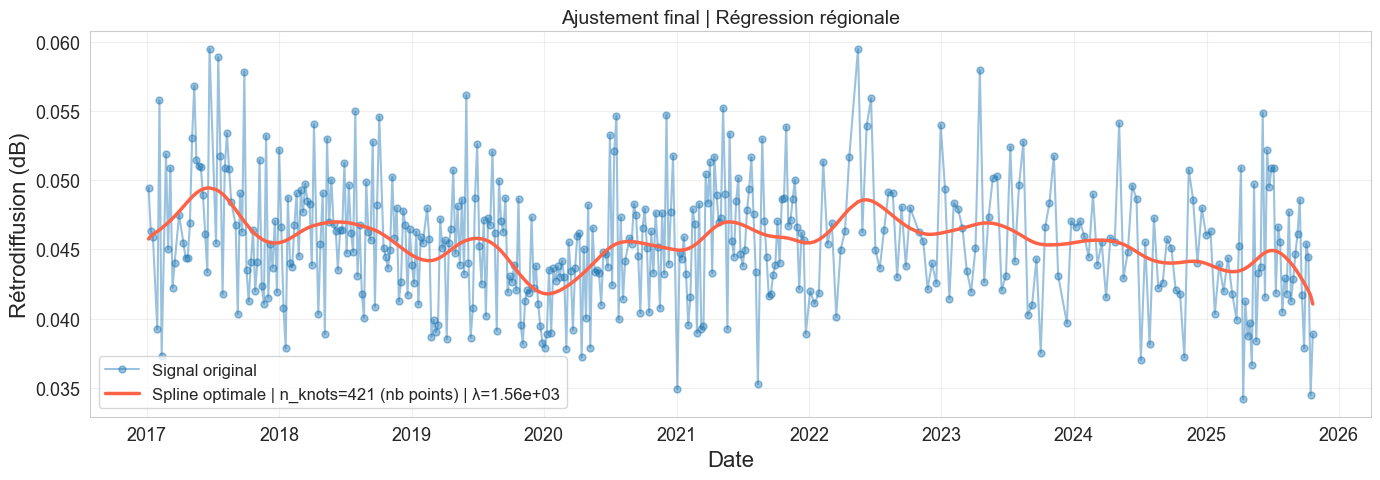

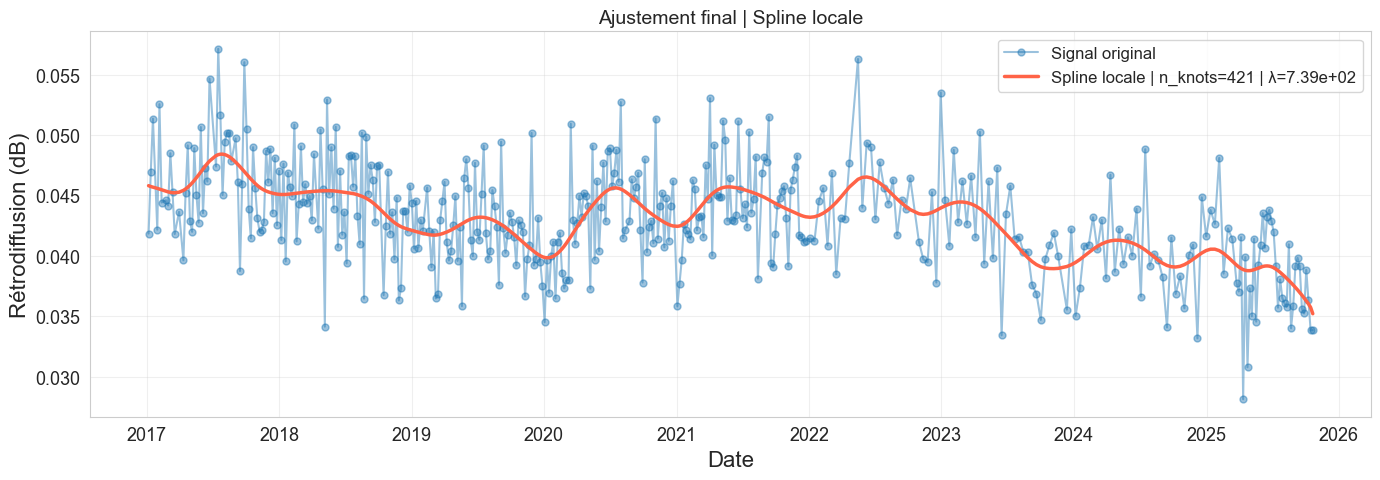

In [74]:
ts_fol = extract_signal(subzone=4, type_veg="fol", polarization="vh", orbite=120, direction="ASC")
ts_defol = extract_signal(subzone=4, type_veg="defol", polarization="vh", orbite=120, direction="ASC")
result_regional = run_regional_spline(ts_fol,use_mallows=False)   # sélection Cp automatique
result_local    = run_local_spline(ts_defol)      # n_knots = len(ts)